---

In [2]:
# %%
import argparse
import time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from arguments import add_arguments
from ilqr.multiLQR import *
from visualize import draw_car
from collections import deque
from ilqr.vehicle_model import *
# %%
def timer_decorator(func):
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        epochs = kwargs.get('epochs', 'unknown number of')
        print(f"Running {func.__name__} for {epochs} epochs took {end_time - start_time} seconds.")
        print(f"The average time for each epoch is {(end_time - start_time)/epochs} seconds.")
        return result
    return wrapper

# %%
def create_global_plan_1():
    start_point = np.array([8, 10, 5])
    end_point = np.array([8.5, 7, 15])
    x_coords = np.concatenate([np.linspace(start_point[0], end_point[0], 20)])
    y_coords = np.concatenate([np.linspace(start_point[1], end_point[1], 20)])
    z_coords = np.concatenate([np.linspace(start_point[2], end_point[2], 20)])
    points = np.array([x_coords, y_coords, z_coords]).T
    return points

def create_global_plan_2():
    start_point = np.array([9, 10, 10])
    end_point = np.array([10, 7, 20])
    x_coords = np.concatenate([np.linspace(start_point[0], end_point[0], 20)])
    y_coords = np.concatenate([np.linspace(start_point[1], end_point[1], 20)])
    z_coords = np.concatenate([np.linspace(start_point[2], end_point[2], 20)])
    points = np.array([x_coords, y_coords, z_coords]).T
    return points

def create_global_plan_3():
    start_point = np.array([6, 9, 10])
    end_point = np.array([10, 11, 20])
    x_coords = np.concatenate([np.linspace(start_point[0], end_point[0], 20)])
    y_coords = np.concatenate([np.linspace(start_point[1], end_point[1], 20)])
    z_coords = np.concatenate([np.linspace(start_point[2], end_point[2], 20)])
    points = np.array([x_coords, y_coords, z_coords]).T
    return points

def create_global_plan_4():
    start_point = np.array([6, 6, 10])
    end_point = np.array([10.5, 10, 15])
    x_coords = np.concatenate([np.linspace(start_point[0], end_point[0], 20)])
    y_coords = np.concatenate([np.linspace(start_point[1], end_point[1], 20)])
    z_coords = np.concatenate([np.linspace(start_point[2], end_point[2], 20)])
    points = np.array([x_coords, y_coords, z_coords]).T
    return points


# %%
class multiAgentSimulator:
    def __init__(self, args):
        self.args = args
        self.model = QuadcopterModel(args)
        self.navigation_agent1 = None
        self.navigation_agent2 = None
        self.navigation_agent3 = None
        self.navigation_agent4 = None
        self.nominal_control = np.zeros((self.args.num_ctrls, self.args.horizon))
        self.nominal_control[0,:] = np.linspace(self.args.acc_control_limits[1], 0, self.args.horizon)
        self.count = 0
        self.count_short = 0
        self.global_plan_agent1 = create_global_plan_1()
        self.global_plan_agent2 = create_global_plan_2()
        self.global_plan_agent3 = create_global_plan_3()
        self.global_plan_agent4 = create_global_plan_4()

        self.current_agent1_state_long = np.concatenate([self.global_plan_agent1[0], np.zeros(9)])
        self.current_agent2_state_long = np.concatenate([self.global_plan_agent2[0], np.zeros(9)])
        self.current_agent3_state_long = np.concatenate([self.global_plan_agent3[0], np.zeros(9)])
        self.current_agent4_state_long = np.concatenate([self.global_plan_agent4[0], np.zeros(9)])
        
        self.last_agent1_states = np.expand_dims(self.simulate_states(
            self.current_agent1_state_long, self.nominal_control), axis=0)
        self.last_agent2_states = np.expand_dims(self.simulate_states(
            self.current_agent2_state_long, self.nominal_control), axis=0)
        self.last_agent3_states = np.expand_dims(self.simulate_states(
            self.current_agent3_state_long, self.nominal_control), axis=0)
        self.last_agent4_states = np.expand_dims(self.simulate_states(
            self.current_agent4_state_long, self.nominal_control), axis=0)
        
        self.agent1_states_long = [self.current_agent1_state_long]
        self.agent2_states_long = [self.current_agent2_state_long]
        self.agent3_states_long = [self.current_agent3_state_long]
        self.agent4_states_long = [self.current_agent4_state_long]
        
        self.agent1_states_short = [self.current_agent1_state_long]
        self.agent2_states_short = [self.current_agent2_state_long]
        self.agent3_states_short = [self.current_agent3_state_long]
        self.agent4_states_short = [self.current_agent4_state_long]
        self.agent1_sigmax = []; self.agent2_sigma_x = []; self.agent3_sigma_x = []; self.agent4_sigma_x = []
        
        self.tmp_agent1_states_long = deque(maxlen=20)
        self.tmp_agent1_controls_long = deque(maxlen=20)
        self.tmp_agent2_states_long = deque(maxlen=20)
        self.tmp_agent2_controls_long = deque(maxlen=20)
        self.tmp_agent3_states_long = deque(maxlen=20)
        self.tmp_agent3_controls_long = deque(maxlen=20)
        self.tmp_agent4_states_long = deque(maxlen=20)
        self.tmp_agent4_controls_long = deque(maxlen=20)

        self.tmp_agent1_lo_12 = deque(maxlen=20)
        self.tmp_agent2_lo_122 = deque(maxlen=20)
        self.tmp_agent2_lo_24 = deque(maxlen=20)
        self.tmp_agent2_lo_244 = deque(maxlen=20)
        self.tmp_agent3_lo_34 = deque(maxlen=20)
        self.tmp_agent3_lo_344 = deque(maxlen=20)
        self.tmp_agent4_lo_42 = deque(maxlen=20)
        self.tmp_agent4_lo_422 = deque(maxlen=20)

        self.agent1_controls_long = []
        self.agent2_controls_long = []
        self.agent3_controls_long = []
        self.agent4_controls_long = []
        self.short_hori_follow_time = []
        # self.global_plan_agent1_cross = self.create_global_plan(25, 70, -5)


        self.create_ilqr_agents(self.args.sim_options)        

    
    def reset(self):
        self.create_ilqr_agents(self.args.sim_options)        
        self.current_agent1_state_long = np.concatenate([self.global_plan_agent1[0], np.zeros(9)])
        self.current_agent2_state_long = np.concatenate([self.global_plan_agent2[0], np.zeros(9)])
        self.current_agent3_state_long = np.concatenate([self.global_plan_agent3[0], np.zeros(9)])
        self.current_agent4_state_long = np.concatenate([self.global_plan_agent4[0], np.zeros(9)])

        self.agent1_states_long = [self.current_agent1_state_long]
        self.agent2_states_long = [self.current_agent2_state_long]
        self.agent3_states_long = [self.current_agent3_state_long]
        self.agent4_states_long = [self.current_agent4_state_long]

        self.agent1_states_short = [self.current_agent1_state_long]
        self.agent2_states_short = [self.current_agent2_state_long]
        self.agent3_states_short = [self.current_agent3_state_long]
        self.agent4_states_short = [self.current_agent4_state_long]

        self.count = 0
        
    def create_ilqr_agents(self, simu_options):
        global_plan_agent1 = self.global_plan_agent1
        global_plan_agent2 = self.global_plan_agent2
        global_plan_agent3 = self.global_plan_agent3
        global_plan_agent4 = self.global_plan_agent4

        self.navigation_agent1 = iLQR(self.args, self.args.car_dims, "1")
        self.navigation_agent1.set_global_plan(global_plan_agent1)
        
        self.navigation_agent2 = iLQR(self.args, self.args.car_dims, "2")
        self.navigation_agent2.set_global_plan(global_plan_agent2)
        
        self.navigation_agent3 = iLQR(self.args, self.args.car_dims, "3")
        self.navigation_agent3.set_global_plan(global_plan_agent3)
        
        self.navigation_agent4 = iLQR(self.args, self.args.car_dims, "4")
        self.navigation_agent4.set_global_plan(global_plan_agent4)
        

    def get_agent1_states(self):
        agent1_states = self.current_agent1_state_long.copy()
        return agent1_states
    
    def get_agent2_states(self):
        agent2_states = self.current_agent2_state_long.copy()
        return agent2_states

    def get_agent3_states(self):
        agent3_states = self.current_agent3_state_long.copy()
        return agent3_states
    def get_agent4_states(self):
        agent4_states = self.current_agent4_state_long.copy()
        return agent4_states
    
    def get_npc_states(self, i):
        return self.NPC_states[:, i:i+self.args.horizon]
    
    # def create_global_plan(self, desired_start_x, desired_end_x, desired_y):
    #     plan_ilqr = []
    #     for i in range(desired_start_x, desired_end_x):
    #         plan_ilqr.append(np.array([i, desired_y]))
    #     plan_ilqr = np.array(plan_ilqr)
    #     return plan_ilqr
        
    def run_model_simulation(self, state, control):
        next_state = self.model.forward_simulate(state, control)
        return next_state
    def run_model_simulation_with_disturbance(self, state, control, noise_type):
        """
        Find the next state of the vehicle given the current state and control input
        """
        # Clips the controller values between min and max accel and steer values
        # print(state[2] + control[0]*Ts)
        next_state = self.model.forward_simulate(state, control)
        if noise_type == 'gaussian':
            noise = np.random.normal(0, self.args.state_gaussian_noise, size=self.args.num_states)
        elif noise_type == 'impulse':
            noise = 0
            if self.count_short % 30 == 0:
                    # print("noisehere")
                    noise = 1 * self.args.state_impulse_noise
                    noise = np.array([0, 0, 0, noise, noise, noise, 0, 0, 0, 0, 0, 0])
        return next_state + noise
    
    def simulate_states(self, init_state, controls):
        states_list = []
        states_list.append(init_state)
        controls = np.hstack((controls, np.zeros((self.args.num_ctrls, self.args.horizon))))
        for i in range(controls.shape[1]):
            next_state = self.run_model_simulation(states_list[i], controls[:, i])
            states_list.append(next_state)
        states_list = np.array(states_list).T
        return states_list
    

    def run_step_ilqr_with_br_short_hori_follow(self, current_epoch):
        assert self.navigation_agent1 != None, "Navigation Agent not initialized"
        # print('step', self.count, self.last_agent2_states.shape)
        # print(lane)
        
        curr_costs = np.zeros(self.args.number_of_agents)
        last_costs = np.zeros(self.args.number_of_agents)
        loop_count = 0
        current_agent1_state = self.current_agent1_state_long
        current_agent2_state = self.current_agent2_state_long
        current_agent3_state = self.current_agent3_state_long
        current_agent4_state = self.current_agent4_state_long

        while True:
            npcs_for_agent1 = np.array([self.last_agent2_states, self.last_agent3_states, self.last_agent4_states])
            states_agent1_hori, controls_agent1, curr_cost_agent1 = self.navigation_agent1.run_step_long(self.get_agent1_states(), npcs_for_agent1, current_epoch)
            current_agent1_state = self.run_model_simulation(self.current_agent1_state_long, controls_agent1[:, 0])
            # print(states_agent1_hori)

            # generate the npcs for agent2
            npcs_for_agent2 = np.array([self.last_agent1_states, self.last_agent3_states, self.last_agent4_states])
            states_agent2_hori, controls_agent2, curr_cost_agent2 = self.navigation_agent2.run_step_long(self.get_agent2_states(), npcs_for_agent2, current_epoch)
            # states_agent2_hori, controls_agent2, curr_cost_agent2 = np.random.rand(12, 21), np.random.rand(4, 20), np.random.rand(1)
            current_agent2_state = self.run_model_simulation(self.current_agent2_state_long, controls_agent2[:, 0])


            npcs_for_agent3 = np.array([self.last_agent1_states, self.last_agent2_states, self.last_agent4_states])
            states_agent3_hori, controls_agent3, curr_cost_agent3 = self.navigation_agent3.run_step_long(self.get_agent3_states(), npcs_for_agent3, current_epoch)
            current_agent3_state = self.run_model_simulation(self.current_agent3_state_long, controls_agent3[:, 0])
            
            npcs_for_agent4 = np.array([self.last_agent1_states, self.last_agent2_states, self.last_agent3_states])
            states_agent4_hori, controls_agent4, curr_cost_agent4 = self.navigation_agent4.run_step_long(self.get_agent4_states(), npcs_for_agent4, current_epoch)
            current_agent4_state = self.run_model_simulation(self.current_agent4_state_long, controls_agent4[:, 0])

            hs = self.args.horizon_short

            curr_costs = np.array([curr_cost_agent1, curr_cost_agent2, curr_cost_agent3, curr_cost_agent4])
            # print(curr_costs)
            loop_count += 1
            print(loop_count, ':', np.linalg.norm(curr_costs-last_costs, ord=2))#, end='\r')
            if np.linalg.norm(curr_costs-last_costs, ord=2) / np.linalg.norm(curr_costs, ord=2)  <= 1e-1 or loop_count >= self.args.loop_tol:
                self.count += 1
                loop_count = 0

                self.current_agent1_state_long = current_agent1_state
                self.current_agent2_state_long = current_agent2_state
                self.current_agent3_state_long = current_agent3_state
                self.current_agent4_state_long = current_agent4_state

                X1, _ = self.set_agent_derivatives_long(nav_agent=self.navigation_agent1, npcs=npcs_for_agent1, current_epoch=current_epoch)
                X2, _ = self.set_agent_derivatives_long(nav_agent=self.navigation_agent2, npcs=npcs_for_agent2, current_epoch=current_epoch)
                X3, _ = self.set_agent_derivatives_long(nav_agent=self.navigation_agent3, npcs=npcs_for_agent3, current_epoch=current_epoch)
                X4, _ = self.set_agent_derivatives_long(nav_agent=self.navigation_agent4, npcs=npcs_for_agent4, current_epoch=current_epoch)
                lo_x_12, lo_x_122 = self.navigation_agent1.constraints.get_obstacle_cost_derivatives_short(X1[:, 1:], np.squeeze(npcs_for_agent1[0], axis=0))
                lo_x_24, lo_x_244 = self.navigation_agent2.constraints.get_obstacle_cost_derivatives_short(X2[:, 1:], np.squeeze(npcs_for_agent2[2], axis=0))
                lo_x_34, lo_x_344 = self.navigation_agent3.constraints.get_obstacle_cost_derivatives_short(X3[:, 1:], np.squeeze(npcs_for_agent3[2], axis=0))
                lo_x_42, lo_x_422 = self.navigation_agent4.constraints.get_obstacle_cost_derivatives_short(X4[:, 1:], np.squeeze(npcs_for_agent3[2], axis=0))
                # print(lo_x_122.shape)
                self.tmp_agent1_lo_12.append(lo_x_12[:, 0])
                self.tmp_agent2_lo_122.append(lo_x_122[:, :, 0])
                self.tmp_agent2_lo_24.append(lo_x_24[:, 0])
                self.tmp_agent2_lo_244.append(lo_x_244[:, :, 0])
                self.tmp_agent3_lo_34.append(lo_x_34[:, 0])
                self.tmp_agent3_lo_344.append(lo_x_344[:, :, 0])
                self.tmp_agent4_lo_42.append(lo_x_42[:, 0])
                self.tmp_agent4_lo_422.append(lo_x_422[:, :, 0])
                # --------------

                self.tmp_agent1_states_long.append(self.current_agent1_state_long)
                self.tmp_agent1_controls_long.append(controls_agent1[:, 0])

                self.tmp_agent2_states_long.append(self.current_agent2_state_long)
                self.tmp_agent2_controls_long.append(controls_agent2[:, 0])

                self.tmp_agent3_states_long.append(self.current_agent3_state_long)
                self.tmp_agent3_controls_long.append(controls_agent3[:, 0])

                self.tmp_agent4_states_long.append(self.current_agent4_state_long)
                self.tmp_agent4_controls_long.append(controls_agent4[:, 0])
                # self.agent2_states_long.append(self.current_agent2_state_long)
                # self.agent2_controls_long.append(controls_agent2[:, 0])

                # if self.args.number_of_agents == 3:
                #     self.agent3_states_long.append(self.current_agent3_state_long)
                #     self.agent3_controls_long.append(controls_agent3[:, 0])
                # print("agent1_states_len=", len(self.agent1_states_long))
                # print(current_agent3_state)
                # to plan the short horizon 
                
                ### INSERT HERE
                time1 = time.time()
                self.short_hori_follow(current_epoch)
                self.agent1_states_long.append(list(self.tmp_agent1_states_long)[-1])
                self.agent1_controls_long.append(list(self.tmp_agent1_controls_long)[-1])
                self.agent2_states_long.append(list(self.tmp_agent2_states_long)[-1])
                self.agent2_controls_long.append(list(self.tmp_agent2_controls_long)[-1])
                self.agent3_states_long.append(list(self.tmp_agent3_states_long)[-1])
                self.agent3_controls_long.append(list(self.tmp_agent3_controls_long)[-1])
                self.agent4_states_long.append(list(self.tmp_agent4_states_long)[-1])
                self.agent4_controls_long.append(list(self.tmp_agent4_controls_long)[-1])
                time2 = time.time()
                time_interval_sh = time2 - time1+0.2
                self.short_hori_follow_time.append(time_interval_sh)
                break
                
            else:
                last_costs = curr_costs
                self.last_agent1_states = np.expand_dims(states_agent1_hori, axis=0)
                self.last_agent2_states = np.expand_dims(states_agent2_hori, axis=0)
                self.last_agent3_states = np.expand_dims(states_agent3_hori, axis=0)
                self.last_agent4_states = np.expand_dims(states_agent4_hori, axis=0)


    def short_hori_follow(self, current_epoch, noise_type='gaussian'):
        distr_type = self.args.distr_type
        hs = self.args.horizon_short
        if (current_epoch+1) % hs == 0 and current_epoch+1 != hs:
            flag_terminal = 0
            self.sub_short_hori_follow(distr_type, noise_type, flag_terminal, current_epoch)
            # print(self.agent1_states_short)

        # plan for the rest
        if current_epoch+1 == self.args.epochs:
            flag_terminal = 1
            extend_traj_agent1 = [list(self.tmp_agent1_states_long)[-1]] * hs
            extend_ctrl_agent1 = [list(self.tmp_agent1_controls_long)[-1]] * hs
            extend_traj_agent2 = [list(self.tmp_agent2_states_long)[-1]] * hs
            extend_ctrl_agent2 = [list(self.tmp_agent2_controls_long)[-1]] * hs
            extend_traj_agent3 = [list(self.tmp_agent3_states_long)[-1]] * hs
            extend_ctrl_agent3 = [list(self.tmp_agent3_controls_long)[-1]] * hs
            extend_traj_agent4 = [list(self.tmp_agent4_states_long)[-1]] * hs
            extend_ctrl_agent4 = [list(self.tmp_agent4_controls_long)[-1]] * hs

            self.tmp_agent1_states_long.extend(extend_traj_agent1)
            self.tmp_agent1_controls_long.extend(extend_ctrl_agent1)
            self.tmp_agent2_states_long.extend(extend_traj_agent2)
            self.tmp_agent2_controls_long.extend(extend_ctrl_agent2)
            self.tmp_agent3_states_long.extend(extend_traj_agent3)
            self.tmp_agent3_controls_long.extend(extend_ctrl_agent3)
            self.tmp_agent4_states_long.extend(extend_traj_agent4)
            self.tmp_agent4_controls_long.extend(extend_ctrl_agent4)

            self.sub_short_hori_follow(distr_type, self.args.noise_type, flag_terminal, current_epoch)

    def sub_short_hori_follow(self, distr_type, noise_type, flag_terminal, current_epoch):
        hs = self.args.horizon_short
        nom_traj1 = np.array(self.tmp_agent1_states_long).T
        nom_ctrl1 = np.array(self.tmp_agent1_controls_long).T
        nom_traj2 = np.array(self.tmp_agent2_states_long).T
        nom_ctrl2 = np.array(self.tmp_agent2_controls_long).T
        nom_traj3 = np.array(self.tmp_agent3_states_long).T
        nom_ctrl3 = np.array(self.tmp_agent3_controls_long).T
        nom_traj4 = np.array(self.tmp_agent4_states_long).T
        nom_ctrl4 = np.array(self.tmp_agent4_controls_long).T
                             
        current_agent1_state_short = self.tmp_agent1_states_long[0]
        current_agent2_state_short = self.tmp_agent2_states_long[0]
        current_agent3_state_short = self.tmp_agent3_states_long[0]
        current_agent4_state_short = self.tmp_agent4_states_long[0]

        for t in range(hs):
            self.count_short += 1
            if distr_type == 'marginal' or distr_type == 'conditional':
                delta_us1, delta_xs1, Sigma_u_inv1, Sigma_u1, Sigma_x1 = self.navigation_agent1.compute_nom_traj_distribution(self.navigation_agent1.tmp_lx, self.navigation_agent1.tmp_lxx, 
                                        self.navigation_agent1.tmp_lu, self.navigation_agent1.tmp_luu, self.navigation_agent1.tmp_lux)  
                delta_us2, delta_xs2, Sigma_u_inv2, Sigma_u2, Sigma_x2 = self.navigation_agent2.compute_nom_traj_distribution(self.navigation_agent2.tmp_lx, self.navigation_agent2.tmp_lxx,
                                        self.navigation_agent2.tmp_lu, self.navigation_agent2.tmp_luu, self.navigation_agent2.tmp_lux)
                delta_us3, delta_xs3, Sigma_u_inv3, Sigma_u3, Sigma_x3 = self.navigation_agent3.compute_nom_traj_distribution(self.navigation_agent3.tmp_lx, self.navigation_agent3.tmp_lxx,
                                        self.navigation_agent3.tmp_lu, self.navigation_agent3.tmp_luu, self.navigation_agent3.tmp_lux)
                delta_us4, delta_xs4, Sigma_u_inv4, Sigma_u4, Sigma_x4 = self.navigation_agent4.compute_nom_traj_distribution(self.navigation_agent4.tmp_lx, self.navigation_agent4.tmp_lxx,
                                        self.navigation_agent4.tmp_lu, self.navigation_agent4.tmp_luu, self.navigation_agent4.tmp_lux)
            elif distr_type == 'joint_conditional':
                # print(self.tmp_agent2_lo_122)
                delta_us1, delta_xs1, Sigma_u_inv1, Sigma_u1, Sigma_x1 = self.navigation_agent1.compute_nom_npc_traj_distribution(self.navigation_agent1.tmp_lx, self.navigation_agent1.tmp_lxx, 
                                        self.navigation_agent1.tmp_lu, self.navigation_agent1.tmp_luu, self.navigation_agent1.tmp_lux, self.tmp_agent1_lo_12, self.tmp_agent2_lo_122)  
                delta_us2, delta_xs2, Sigma_u_inv2, Sigma_u2, Sigma_x2 = self.navigation_agent2.compute_nom_npc_traj_distribution(self.navigation_agent2.tmp_lx, self.navigation_agent2.tmp_lxx,
                                        self.navigation_agent2.tmp_lu, self.navigation_agent2.tmp_luu, self.navigation_agent2.tmp_lux, self.tmp_agent2_lo_24, self.tmp_agent2_lo_244)                
                delta_us3, delta_xs3, Sigma_u_inv3, Sigma_u3, Sigma_x3 = self.navigation_agent3.compute_nom_npc_traj_distribution(self.navigation_agent3.tmp_lx, self.navigation_agent3.tmp_lxx,
                                        self.navigation_agent3.tmp_lu, self.navigation_agent3.tmp_luu, self.navigation_agent3.tmp_lux, self.tmp_agent3_lo_34, self.tmp_agent3_lo_344)
                delta_us4, delta_xs4, Sigma_u_inv4, Sigma_u4, Sigma_x4 = self.navigation_agent4.compute_nom_npc_traj_distribution(self.navigation_agent4.tmp_lx, self.navigation_agent4.tmp_lxx,
                                        self.navigation_agent4.tmp_lu, self.navigation_agent4.tmp_luu, self.navigation_agent4.tmp_lux, self.tmp_agent4_lo_42, self.tmp_agent4_lo_422)
            
            self.agent1_sigmax.append(Sigma_x1); self.agent2_sigma_x.append(Sigma_x2); self.agent3_sigma_x.append(Sigma_x3); self.agent4_sigma_x.append(Sigma_x4)
            # print('Sigma_u1, Sigma_x1, Sigma_u2, Sigma_x2', Sigma_u1.shape, Sigma_x1.shape, Sigma_u2.shape, Sigma_x2.shape)
            # print(Sigma_u1)
            if distr_type == 'marginal':
                Delta_t1 = self.navigation_agent1.get_state_cost_marginal(Sigma_x1, nom_traj1)
                Delta_t2 = self.navigation_agent2.get_state_cost_marginal(Sigma_x2, nom_traj2)
                Delta_t3 = self.navigation_agent3.get_state_cost_marginal(Sigma_x3, nom_traj3)
                Delta_t4 = self.navigation_agent4.get_state_cost_marginal(Sigma_x4, nom_traj4)
                if current_epoch >= self.args.epochs - self.args.horizon:
                    mag = self.args.horizon - self.args.epochs + current_epoch
                    self.navigation_agent1.constraints.state_cost_t = Delta_t1[1:]*mag**2
                    self.navigation_agent2.constraints.state_cost_t = Delta_t2[1:]*mag**2
                    self.navigation_agent3.constraints.state_cost_t = Delta_t3[1:]*mag**2
                    self.navigation_agent4.constraints.state_cost_t = Delta_t4[1:]*mag**2
                else:
                    self.navigation_agent1.constraints.state_cost_t = Delta_t1[1:]
                    self.navigation_agent2.constraints.state_cost_t = Delta_t2[1:]
                    self.navigation_agent3.constraints.state_cost_t = Delta_t3[1:]
                    self.navigation_agent4.constraints.state_cost_t = Delta_t4[1:]

                X_short1, U_short1, cost1 = self.navigation_agent1.run_step_short_marginal(current_agent1_state_short, nom_traj1, nom_ctrl1, t)
                X_short2, U_short2, cost2 = self.navigation_agent2.run_step_short_marginal(current_agent2_state_short, nom_traj2, nom_ctrl2, t)
                X_short3, U_short3, cost3 = self.navigation_agent3.run_step_short_marginal(current_agent3_state_short, nom_traj3, nom_ctrl3, t)
                X_short4, U_short4, cost4 = self.navigation_agent4.run_step_short_marginal(current_agent4_state_short, nom_traj4, nom_ctrl4, t)

                current_agent1_state_short = self.run_model_simulation_with_disturbance(current_agent1_state_short, U_short1[:, 0], noise_type)
                current_agent2_state_short = self.run_model_simulation_with_disturbance(current_agent2_state_short, U_short2[:, 0], noise_type)
                current_agent3_state_short = self.run_model_simulation_with_disturbance(current_agent3_state_short, U_short3[:, 0], noise_type)
                current_agent4_state_short = self.run_model_simulation_with_disturbance(current_agent4_state_short, U_short4[:, 0], noise_type)

            elif distr_type == 'conditional'or distr_type == 'joint_conditional': 
                Delta_t1 = self.navigation_agent1.get_state_cost_single_conditional(Sigma_x1, nom_traj1, flag_terminal)
                Delta_t2 = self.navigation_agent2.get_state_cost_single_conditional(Sigma_x2, nom_traj2, flag_terminal)
                Delta_t3 = self.navigation_agent3.get_state_cost_single_conditional(Sigma_x3, nom_traj3, flag_terminal)
                Delta_t4 = self.navigation_agent4.get_state_cost_single_conditional(Sigma_x4, nom_traj4, flag_terminal)
                # self.navigation_agent1.constraints.total_state_cost_t.append(Delta_t1[1:])
                # self.navigation_agent2.constraints.total_state_cost_t.append(Delta_t2[1:])
                # self.navigation_agent3.constraints.total_state_cost_t.append(Delta_t3[1:])
                # self.navigation_agent4.constraints.total_state_cost_t.append(Delta_t4[1:])
                if current_epoch >= self.args.epochs - self.args.horizon:
                    self.navigation_agent1.constraints.state_cost_t = Delta_t1[1:]*1000
                    self.navigation_agent2.constraints.state_cost_t = Delta_t2[1:]*1000
                    self.navigation_agent3.constraints.state_cost_t = Delta_t3[1:]*1000
                    self.navigation_agent4.constraints.state_cost_t = Delta_t4[1:]*1000
                else:
                    self.navigation_agent1.constraints.state_cost_t = Delta_t1[1:]
                    self.navigation_agent2.constraints.state_cost_t = Delta_t2[1:]
                    self.navigation_agent3.constraints.state_cost_t = Delta_t3[1:]
                    self.navigation_agent4.constraints.state_cost_t = Delta_t4[1:]

                X_short1, U_short1, cost1 = self.navigation_agent1.run_step_short_conditional(current_agent1_state_short, nom_traj1, nom_ctrl1, 0)
                X_short2, U_short2, cost2 = self.navigation_agent2.run_step_short_conditional(current_agent2_state_short, nom_traj2, nom_ctrl2, 0)
                X_short3, U_short3, cost3 = self.navigation_agent3.run_step_short_conditional(current_agent3_state_short, nom_traj3, nom_ctrl3, 0)
                X_short4, U_short4, cost4 = self.navigation_agent4.run_step_short_conditional(current_agent4_state_short, nom_traj4, nom_ctrl4, 0)

                current_agent1_state_short = self.run_model_simulation_with_disturbance(current_agent1_state_short, U_short1[:, 0], noise_type)
                current_agent2_state_short = self.run_model_simulation_with_disturbance(current_agent2_state_short, U_short2[:, 0], noise_type)
                current_agent3_state_short = self.run_model_simulation_with_disturbance(current_agent3_state_short, U_short3[:, 0], noise_type)
                current_agent4_state_short = self.run_model_simulation_with_disturbance(current_agent4_state_short, U_short4[:, 0], noise_type)
            
            self.agent1_states_short.append(list(X_short1.T)[0])
            self.agent2_states_short.append(list(X_short2.T)[0])
            self.agent3_states_short.append(list(X_short3.T)[0])
            self.agent4_states_short.append(list(X_short4.T)[0])
            self.navigation_agent1.total_cost += cost1
            self.navigation_agent2.total_cost += cost2
            self.navigation_agent3.total_cost += cost3
            self.navigation_agent4.total_cost += cost4



    def set_agent_derivatives_long(self, nav_agent, npcs, current_epoch):
        # get the cost derivatives
        agent_state = self.get_agent1_states()
        nav_agent.local_planner.set_agent_state(agent_state)
        ref_traj, poly_coeff_y, poly_coeff_z = nav_agent.local_planner.get_local_plan()
        X_0 = agent_state
        U = nav_agent.control_seq_long
        X = nav_agent.get_nominal_trajectory(X_0, U)
        fx = nav_agent.vehicle_model.get_A_matrix(X[:, 1:],  U[:, :], self.args.horizon)
        fu = nav_agent.vehicle_model.get_B_matrix(X[:, 1:],  U[:, :], self.args.horizon)
        l_x, l_xx, l_u, l_uu, l_ux = nav_agent.constraints.get_cost_derivatives_long(X[:, 1:], U, poly_coeff_y, poly_coeff_z, ref_traj[:, 0], npcs, current_epoch) 
        # print(lo_x_12.shape, lo_x_122.shape)
        # print(l_x.shape, l_xx.shape, l_u.shape, l_uu.shape, l_ux.shape)
        nav_agent.tmp_lx.append(l_x[:, 0])
        nav_agent.tmp_lxx.append(l_xx[:, :, 0])
        nav_agent.tmp_lu.append(l_u[:, 0])
        nav_agent.tmp_luu.append(l_uu[:, :, 0])
        nav_agent.tmp_lux.append(l_ux[:, :, 0])
        nav_agent.tmp_fx.append(fx[:, :, 0])
        nav_agent.tmp_fu.append(fu[:, :, 0])
        # nav_agent.total_lx.append(l_x[:,0]); nav_agent.total_lxx.append(l_xx[:,:,0]); nav_agent.total_lu.append(l_u[:,0]); 
        # nav_agent.total_luu.append(l_uu[:,:,0]); nav_agent.total_lux.append(l_ux[:,:,0])
        # nav_agent.total_fx.append(fx[:,:,0]); nav_agent.total_fu.append(fu[:,:,0])
        return X, U

    def run_epochs_ilqr(self, epochs):
        self.reset()
        time_start = time.time()
        for i in range(epochs):
            self.run_step_ilqr_with_br_short_hori_follow(i)
            print('\n')
            print('Step:', self.count)
        time_end = time.time()
        time_cost = time_end - time_start - sum(self.short_hori_follow_time)
        print("for long-term ilqr, time cost = ", time_cost, "avg time cost = ", time_cost/epochs)
        print("for short-term ilqr, time cost = ", sum(self.short_hori_follow_time)/epochs)
        return time_cost, time_cost/epochs, sum(self.short_hori_follow_time)/epochs

    def compute_distance(self, agentx_states, agenty_states):
        return np.linalg.norm(np.array(agentx_states)[:,:2]-np.array(agenty_states)[:,:2], 2, axis=1)
    
    def visualize_frame(self, X, Y, YAW, ox = [], oy = []):
        colors = ['r', 'b', 'g', 'c', 'm', 'y', 'k'];
        plt.figure(figsize=(6,6))
        plt.plot(ox, oy, "sk")
        for k in range(len(X[0])):
            plt.cla()
            plt.plot([0, 35], [-10, -10], color='black')
            plt.plot([55, 90], [-10, -10], color='black')
            plt.plot([45, 45], [10, 45], color='#ff9933', linestyle='--')
            plt.plot([0, 35], [10, 10], color='black')
            plt.plot([55, 90], [10, 10], color='black')
            plt.plot([45, 45], [-10, -45], color='#ff9933', linestyle='--')
            plt.plot([35, 35], [-10, -45], color='black')
            plt.plot([55, 55], [-10, -45], color='black')
            plt.plot([0, 35], [0, 0], color='#ff9933', linestyle='--')
            plt.plot([55, 55], [10, 45], color='black')
            plt.plot([35, 35], [10, 45], color='black')
            plt.plot([55, 90], [0, 0], color='#ff9933', linestyle='--')             
            idx_car = 0
            for x, y, yaw in zip(X, Y, YAW):
                plt.plot(x, y, linewidth=1.5, color=colors[idx_car], label='Agent '+str(idx_car+1))
                draw_car(x[-1], y[-1], yaw[-1], 'dimgray')
                draw_car(x[k], y[k], yaw[k], colors[idx_car])
                idx_car += 1
                plt.plot(self.global_plan_agent1[::4,0], 
                self.global_plan_agent1[::4,1], 
                'o', color=(1, 0, 0, 0.2), label='Global Plan Agent 1')        
                plt.plot(self.global_plan_agent2[::3,0], 
                self.global_plan_agent2[::3,1], 
                '*', color=(0, 0, 1, 0.2), label='Global Plan Agent 2')  
                if self.args.number_of_agents == 3:
                    plt.plot(self.global_plan_agent3[::3,0], 
                    self.global_plan_agent3[::3,1], 
                    '+', color=(0, 1, 0, 0.5), label='Global Plan Agent 3')  

            plt.legend()
            plt.title("iLQR Solution")
            plt.axis("equal")
            plt.pause(0.1)

        plt.show()
    
    def visualize_all(self, interval):
        if self.args.number_of_agents == 2:
            self.visualize_frame([list(np.array(self.agent1_states_long)[::interval, 0]), list(np.array(self.agent2_states_long)[::interval, 0])],
                [list(np.array(self.agent1_states_long)[::interval, 1]), list(np.array(self.agent2_states_long)[::interval, 1])], 
                [list(np.array(self.agent1_states_long)[::interval, 3]), list(np.array(self.agent2_states_long)[::interval, 3])])
        elif self.args.number_of_agents == 3:
            self.visualize_frame([list(np.array(self.agent1_states_long)[::interval, 0]), list(np.array(self.agent2_states_long)[::interval, 0]), list(np.array(self.agent3_states_long)[::interval, 0])],
                [list(np.array(self.agent1_states_long)[::interval, 1]), list(np.array(self.agent2_states_long)[::interval, 1]), list(np.array(self.agent3_states_long)[::interval, 1])], 
                [list(np.array(self.agent1_states_long)[::interval, 3]), list(np.array(self.agent2_states_long)[::interval, 3]), list(np.array(self.agent3_states_long)[::interval, 3])])

    def visualize_all_short(self, interval):
        if self.args.number_of_agents == 2:
            self.visualize_frame([list(np.array(self.agent1_states_short)[::interval, 0]), list(np.array(self.agent2_states_short)[::interval, 0])],
                [list(np.array(self.agent1_states_short)[::interval, 1]), list(np.array(self.agent2_states_short)[::interval, 1])], 
                [list(np.array(self.agent1_states_short)[::interval, 3]), list(np.array(self.agent2_states_short)[::interval, 3])])
        elif self.args.number_of_agents == 3:
            self.visualize_frame([list(np.array(self.agent1_states_short)[::interval, 0]), list(np.array(self.agent2_states_short)[::interval, 0]), list(np.array(self.agent3_states_long)[::interval, 0])],
                [list(np.array(self.agent1_states_short)[::interval, 1]), list(np.array(self.agent2_states_short)[::interval, 1]), list(np.array(self.agent3_states_long)[::interval, 1])], 
                [list(np.array(self.agent1_states_short)[::interval, 3]), list(np.array(self.agent2_states_short)[::interval, 3]), list(np.array(self.agent3_states_long)[::interval, 3])])
# %% [markdown]
# ---


In [3]:
if __name__ == "__main__":
    total_time_cost = []
    avg_long_cost = []
    avg_short_cost = []
    argparser = argparse.ArgumentParser([])
    add_arguments(argparser)
    argparser.add_argument('--number_of_agents', type=int, default=4, help='Number of agents')
    argparser.add_argument('--sim_options', default="cross", type=str, help="Type of simulation, cross")
    argparser.add_argument('--epochs', type=int, default=80, help='Total number of epochs for all agents')
    argparser.add_argument('--draw_interval', type=int, default=2, help='Interval for drawing the simulation')
    argparser.add_argument('--loop_tol', type=int, default=3, help='tolerance of the loop')
    argparser.add_argument('--distr_type', type=str, default='conditional', help='tracking type')
    argparser.add_argument('--noise_type', type=str, default='impulse', help='noise type')
    argparser.add_argument('--state_gaussian_noise', nargs="*", type=float, default=[0.05]*12, help='State disturbance')
    argparser.add_argument('--state_impulse_noise', nargs="*", type=float, default=5, help='State disturbance: x, y, v, yaw')

    args = argparser.parse_args([])

    for i in range(20): # 300min
        masim = multiAgentSimulator(args)
        total, long, short = masim.run_epochs_ilqr(epochs=args.epochs)
        total_time_cost.append(total); avg_long_cost.append(long); avg_short_cost.append(short)

1 : 526.4313446760589
2 : 88.13699435367532
3 : 58.58887575683506


Step: 1
1 : 699.9523133585233
2 : 4.065480990062784


Step: 2
1 : 709.1491527717242
2 : 8.520435030645658


Step: 3
1 : 708.3517130030284
2 : 8.42509972815713


Step: 4
1 : 717.4178507806074
2 : 3.266754639861938


Step: 5
1 : 730.4576877160754
2 : 3.1428724606918905


Step: 6
1 : 714.9897958339888
2 : 4.597356989001432


Step: 7
1 : 722.6735440087938
2 : 1.9665310905903637


Step: 8
1 : 740.7784849045529
2 : 2.795034640813574


Step: 9
1 : 762.1158629528747
2 : 2.1333156608310655


Step: 10
1 : 753.1427829854401
2 : 1.8485569519161305


Step: 11
1 : 766.1873488186765
2 : 2.960938258951307


Step: 12
1 : 786.8296025470045
2 : 1.413266291274773


Step: 13
1 : 792.8676544670866
2 : 1.3978928705843183


Step: 14
1 : 792.6574355906774
2 : 3.064298706626834


Step: 15
1 : 798.063642282372
2 : 3.439920618363913


Step: 16
1 : 799.7515582163428
2 : 3.8231370283555206


Step: 17
1 : 810.5155750699845
2 : 4.703906534462016


St

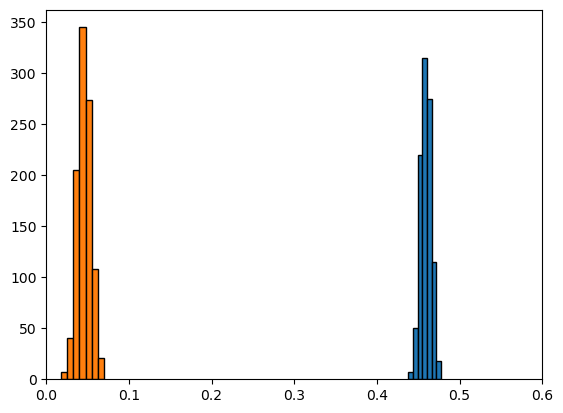

In [25]:
import numpy as np
import matplotlib.pyplot as plt
# mu = np.average(avg_long_cost) # 0.4586398302018643
mu1 = 0.4586398302018643
# std = np.std(avg_long_cost) # 0.006427501202996848
std1 = 0.006427501202996848
mu2 = 0.045523771842320766
std2 = 0.00831968659585281
plt.hist(np.random.normal(mu1, std1, 1000), bins=7, edgecolor='black')
plt.hist(np.random.normal(mu2, std2, 1000), bins=7, edgecolor='black')
plt.xlim(0, 0.6)
plt.show()

In [4]:
def get_trajs_long():
    agent1_traj = np.array(masim.agent1_states_long)[:, :3]
    agent2_traj = np.array(masim.agent2_states_long)[:, :3]
    agent3_traj = np.array(masim.agent3_states_long)[:, :3]
    agent4_traj = np.array(masim.agent4_states_long)[:, :3]
    return [agent1_traj, agent2_traj, agent3_traj, agent4_traj]

def get_trajs_short():
    agent1_traj = np.array(masim.agent1_states_short)[:, :3]
    agent2_traj = np.array(masim.agent2_states_short)[:, :3]
    agent3_traj = np.array(masim.agent3_states_short)[:, :3]
    agent4_traj = np.array(masim.agent4_states_short)[:, :3]
    return [agent1_traj, agent2_traj, agent3_traj, agent4_traj]

def draw_traj(trajs, ref_trajs, t=0, elev=5, azim=None):
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=elev, azim=azim)
    for idx, traj in enumerate(trajs):
        ax.scatter(traj[0, 0], traj[0, 1], traj[0, 2], marker='*', color=colors[idx])
        ax.scatter(traj[-1, 0], traj[-1, 1], traj[-1, 2], marker='x', color=colors[idx])
        ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], linestyle='--', color=colors[idx])
        ax.scatter(traj[t, 0], traj[t, 1], traj[t, 2], color=colors[idx])
        ax.plot(traj[:t, 0], traj[:t, 1], traj[:t, 2], label='Robot'+str(idx+1), color=colors[idx])


    for idx, ref_traj in enumerate(ref_trajs):
        ax.plot(ref_traj[:, 0], ref_traj[:, 1], ref_traj[:, 2], linestyle='dotted', color=colors[idx], alpha=0.8)
    
    
    ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))

    plt.show()

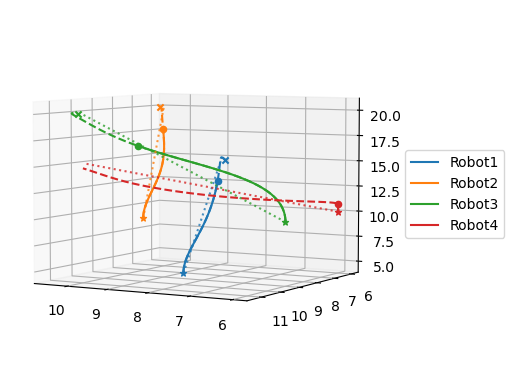

In [5]:
draw_traj(get_trajs_long(), [create_global_plan_1(), create_global_plan_2(), create_global_plan_3(), create_global_plan_4()], 
          t=40, elev=5, azim=120)

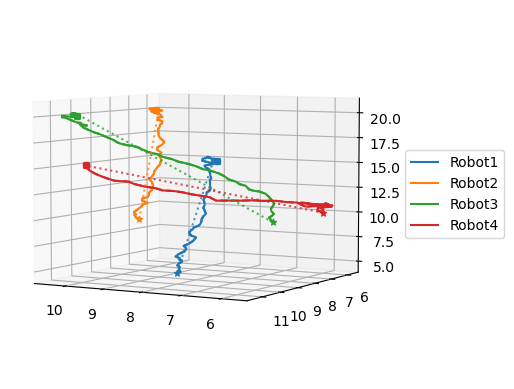

In [6]:
# draw_traj([agent1_traj, agent2_traj], [create_global_plan_1(), create_global_plan_2()], 15, None)
# draw_traj([create_global_plan_1(), create_global_plan_2(), create_global_plan_3(), create_global_plan_4()], [], 0, 45)
# draw_traj(get_trajs_short(), [create_global_plan_1(), create_global_plan_2(), create_global_plan_3(), create_global_plan_4()], 
#           t=0, elev=5, azim=120)
# draw_traj(get_trajs_short(), [create_global_plan_1(), create_global_plan_2(), create_global_plan_3(), create_global_plan_4()], 
#           t=40, elev=5, azim=120)
draw_traj(get_trajs_short(), [create_global_plan_1(), create_global_plan_2(), create_global_plan_3(), create_global_plan_4()], 
          t=80, elev=5, azim=120)
# draw_traj(get_trajs_short(), [create_global_plan_1(), create_global_plan_2(), create_global_plan_3(), create_global_plan_4()], 
#           t=70, elev=None, azim=None)

In [181]:
agent1_mux = np.array(masim.agent1_states_long)[1:,:]
agent2_mux = np.array(masim.agent2_states_long)[1:,:]
agent3_mux = np.array(masim.agent3_states_long)[1:,:]
agent4_mux = np.array(masim.agent4_states_long)[1:,:]
agent1_sigmax = np.array(masim.navigation_agent1.constraints.total_state_cost_t)[:,0,:,:]
agent2_sigmax = np.array(masim.navigation_agent2.constraints.total_state_cost_t)[:,0,:,:]
agent3_sigmax = np.array(masim.navigation_agent3.constraints.total_state_cost_t)[:,0,:,:]
agent4_sigmax = np.array(masim.navigation_agent4.constraints.total_state_cost_t)[:,0,:,:]

sample_trajs1 = []; sample_trajs2 = []; sample_trajs3 = []; sample_trajs4 = []
for i in range(50):
    samples1 = []; samples2 = []; samples3 = []; samples4 = []
    for t in range(80):
        samples1.append(np.random.multivariate_normal(mean=agent1_mux[t], 
                                                     cov=np.linalg.inv(agent1_sigmax[t])*1))
        samples2.append(np.random.multivariate_normal(mean=agent2_mux[t],
                                                     cov=np.linalg.inv(agent2_sigmax[t])*1))
        samples3.append(np.random.multivariate_normal(mean=agent3_mux[t],
                                                     cov=np.linalg.inv(agent3_sigmax[t])*1))
        samples4.append(np.random.multivariate_normal(mean=agent4_mux[t],
                                                     cov=np.linalg.inv(agent4_sigmax[t])*1))
        
    sample_traj1 = np.array(samples1)[:,:3]; sample_traj2 = np.array(samples2)[:,:3]
    sample_traj3 = np.array(samples3)[:,:3]; sample_traj4 = np.array(samples4)[:,:3]
    sample_trajs1.append(sample_traj1); sample_trajs2.append(sample_traj2)
    sample_trajs3.append(sample_traj3); sample_trajs4.append(sample_traj4)

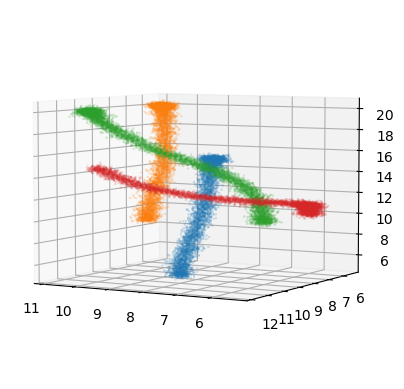

In [182]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax.view_init(elev=5, azim=120)
for traj in sample_trajs1:
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], linestyle='dotted', alpha=0.2, color=colors[0])
for traj in sample_trajs2:
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], linestyle='dotted', alpha=0.2, color=colors[1])
for traj in sample_trajs3:
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], linestyle='dotted', alpha=0.2, color=colors[2])
for traj in sample_trajs4:
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], linestyle='dotted', alpha=0.2, color=colors[3])

plt.show()

In [14]:
dist_sample1 = []
for i, traj in enumerate(sample_trajs1):
    dist_traj_s1 = []
    for t in range(30):
        dist = np.sum(traj[t]-agent1_mux[t, :3])
        dist_traj_s1.append(dist)
    dist_traj_s1 = np.array(dist_traj_s1)
    dist_sample1.append(dist_traj_s1)
dists1 = np.array(dist_sample1)

(20,)

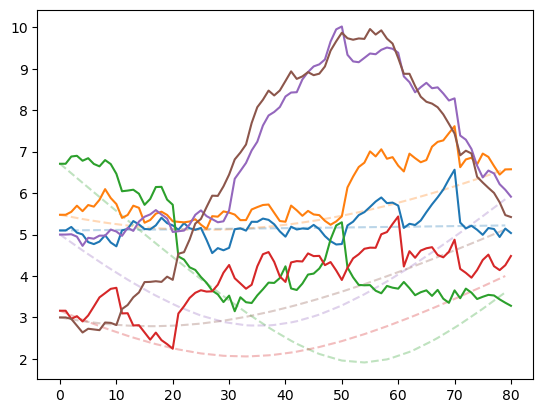

In [6]:
def compute_distance(agent1, agent2):
    return np.linalg.norm(np.array(agent1)[:,:3]-np.array(agent2)[:,:3], 2, axis=1)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
x = np.linspace(0, 1, 20)  # 生成 20 个均匀分布的点
x_new = np.linspace(0, 1, 80)  # 生成 80 个均匀分布的点

plt.plot(np.interp(x_new, x, compute_distance(create_global_plan_1(), create_global_plan_2())), label='Ref-Dist-1-2', linestyle='--', alpha=0.3, color=colors[0])
plt.plot(np.interp(x_new, x, compute_distance(create_global_plan_1(), create_global_plan_3())), label='Ref-Dist-1-3', linestyle='--', alpha=0.3, color=colors[1])
plt.plot(np.interp(x_new, x, compute_distance(create_global_plan_1(), create_global_plan_4())), label='Ref-Dist-1-4', linestyle='--', alpha=0.3, color=colors[2])
plt.plot(np.interp(x_new, x, compute_distance(create_global_plan_2(), create_global_plan_3())), label='Ref-Dist-2-3', linestyle='--', alpha=0.3, color=colors[3])
plt.plot(np.interp(x_new, x, compute_distance(create_global_plan_2(), create_global_plan_4())), label='Ref-Dist-2-4', linestyle='--', alpha=0.3, color=colors[4])
plt.plot(np.interp(x_new, x, compute_distance(create_global_plan_3(), create_global_plan_4())), label='Ref-Dist-3-4', linestyle='--', alpha=0.3, color=colors[5])
plt.plot(compute_distance(masim.agent1_states_short, masim.agent2_states_short), label='Dist-1-2', color=colors[0])
plt.plot(compute_distance(masim.agent1_states_short, masim.agent3_states_short), label='Dist-1-3', color=colors[1])
plt.plot(compute_distance(masim.agent1_states_short, masim.agent4_states_short), label='Dist-1-4', color=colors[2])
plt.plot(compute_distance(masim.agent2_states_short, masim.agent3_states_short), label='Dist-2-3', color=colors[3])
plt.plot(compute_distance(masim.agent2_states_short, masim.agent4_states_short), label='Dist-2-4', color=colors[4])
plt.plot(compute_distance(masim.agent3_states_short, masim.agent4_states_short), label='Dist-3-4', color=colors[5])

# plt.axhline(y=2, color='black', linestyle='dotted', alpha=0.5)
# plt.text(-1, 1.8, 'Min Feasible Distance', color='black', ha='left', va='top', alpha=0.5)
# plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
# for dist in dists1:
#     plt.plot(dist, color=colors[0], alpha=0.1)
plt.show()

In [8]:
import pandas as pd

MatA = pd.read_csv('matrix_A.csv', header=None)
MatB = pd.read_csv('matrix_B.csv', header=None)


# 定义一个函数来生成 Python 赋值语句
def generate_python_code(df):
    code_lines = []
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            expression = df.iloc[i, j]
            if expression != 0 and expression != '0':
                code_lines.append(f"B[{i}, {j}, :] = {expression}")
    return code_lines

# 生成代码
python_code = generate_python_code(MatB)

# 输出生成的代码
for line in python_code:
    print(line)


B[3, 0, :] = (dt*sin(ty)*sin(tz))/m
B[4, 0, :] = -(dt*cos(tz)*sin(ty))/m
B[5, 0, :] = (dt*cos(ty))/m
B[6, 1, :] = dt**2/Ix
B[6, 2, :] = (dt**2*sin(tx)*sin(ty))/(Iy*cos(ty))
B[6, 3, :] = (dt**2*cos(tx)*sin(ty))/(Iz*cos(ty))
B[7, 2, :] = (dt**2*cos(tx))/Iy
B[7, 3, :] = -(dt**2*sin(tx))/Iz
B[8, 2, :] = (dt**2*sin(tx))/(Iy*cos(ty))
B[8, 3, :] = (dt**2*cos(tx))/(Iz*cos(ty))
B[9, 1, :] = dt/Ix
B[9, 2, :] = (dt*sin(tx)*sin(ty))/(Iy*cos(ty))
B[9, 3, :] = (dt*cos(tx)*sin(ty))/(Iz*cos(ty))
B[10, 2, :] = (dt*cos(tx))/Iy
B[10, 3, :] = -(dt*sin(tx))/Iz
B[11, 2, :] = (dt*sin(tx))/(Iy*cos(ty))
B[11, 3, :] = (dt*cos(tx))/(Iz*cos(ty))


In [1]:
import numpy as np
A = np.zeros((12, 12, 2))
x = np.random.rand(12, 2)
u = np.random.rand(4, 2)
def cos(x):
    return np.cos(x)
def sin(x):
    return np.sin(x)
Ix = 2; Iy = 2; Iz = 4
m = 1; dt=0.1; kd = 2
k = 1; b = 1; L = 1
px, py, pz = x[0], x[1], x[2]
pdotx, pdoty, pdotz = x[3], x[4], x[5]
tx, ty, tz = x[6], x[7], x[8]
tdotx, tdoty, tdotz = x[9], x[10], x[11]
Tau, taux, tauy, tauz = u[0], u[1], u[2], u[3]

A[0, 0, :] = 1
A[0, 3, :] = dt
A[1, 1, :] = 1
A[1, 4, :] = dt
A[2, 2, :] = 1
A[2, 5, :] = dt
A[3, 3, :] = 1 - dt*kd
A[3, 7, :] = (Tau*dt*cos(ty)*sin(tz))/m
A[3, 8, :] = (Tau*dt*cos(tz)*sin(ty))/m
A[4, 4, :] = 1 - dt*kd
A[4, 7, :] = -(Tau*dt*cos(ty)*cos(tz))/m
A[4, 8, :] = (Tau*dt*sin(ty)*sin(tz))/m
A[5, 5, :] = 1 - dt*kd
A[5, 7, :] = -(Tau*dt*sin(ty))/m
A[6, 6, :] = (Ix*Iy*Iz*cos(ty) - Iy*Iz**2*dt**2*tdoty**2*cos(ty)*sin(tx)**2 + Iy**2*Iz*dt**2*tdoty**2*cos(ty)*sin(tx)**2 - Iy*Iz**2*dt**2*tdotz**2*cos(tx)**2*cos(ty)**3 + Iy**2*Iz*dt**2*tdotz**2*cos(tx)**2*cos(ty)**3 + Iy*Iz**2*dt**2*tdotz**2*cos(ty)**3*sin(tx)**2 - Iy**2*Iz*dt**2*tdotz**2*cos(ty)**3*sin(tx)**2 + Ix*Iz*dt**2*tauy*cos(tx)*sin(ty) + Iy*Iz**2*dt**2*tdoty**2*cos(tx)**2*cos(ty) - Iy**2*Iz*dt**2*tdoty**2*cos(tx)**2*cos(ty) - Ix*Iy*dt**2*tauz*sin(tx)*sin(ty) + Ix*Iy**2*dt**2*tdotz**2*cos(tx)**2*cos(ty)*sin(ty)**2 - Ix**2*Iy*dt**2*tdotz**2*cos(tx)**2*cos(ty)*sin(ty)**2 - Ix*Iz**2*dt**2*tdotz**2*cos(tx)**2*cos(ty)*sin(ty)**2 + Ix**2*Iz*dt**2*tdotz**2*cos(tx)**2*cos(ty)*sin(ty)**2 - Ix*Iy**2*dt**2*tdotz**2*cos(ty)*sin(tx)**2*sin(ty)**2 + Ix**2*Iy*dt**2*tdotz**2*cos(ty)*sin(tx)**2*sin(ty)**2 + Ix*Iz**2*dt**2*tdotz**2*cos(ty)*sin(tx)**2*sin(ty)**2 - Ix**2*Iz*dt**2*tdotz**2*cos(ty)*sin(tx)**2*sin(ty)**2 - 2*Ix*Iy**2*dt**2*tdoty*tdotz*cos(tx)*sin(tx)*sin(ty)**2 + 2*Ix**2*Iy*dt**2*tdoty*tdotz*cos(tx)*sin(tx)*sin(ty)**2 + Ix*Iy**2*dt**2*tdotx*tdotz*cos(ty)*sin(tx)**2*sin(ty) - Ix**2*Iy*dt**2*tdotx*tdotz*cos(ty)*sin(tx)**2*sin(ty) + 2*Ix*Iz**2*dt**2*tdoty*tdotz*cos(tx)*sin(tx)*sin(ty)**2 - 2*Ix**2*Iz*dt**2*tdoty*tdotz*cos(tx)*sin(tx)*sin(ty)**2 - Ix*Iz**2*dt**2*tdotx*tdotz*cos(ty)*sin(tx)**2*sin(ty) + Ix**2*Iz*dt**2*tdotx*tdotz*cos(ty)*sin(tx)**2*sin(ty) + 2*Ix*Iy**2*dt**2*tdotx*tdoty*cos(tx)*sin(tx)*sin(ty) - 2*Ix**2*Iy*dt**2*tdotx*tdoty*cos(tx)*sin(tx)*sin(ty) - 2*Ix*Iz**2*dt**2*tdotx*tdoty*cos(tx)*sin(tx)*sin(ty) + 2*Ix**2*Iz*dt**2*tdotx*tdoty*cos(tx)*sin(tx)*sin(ty) - Ix*Iy**2*dt**2*tdotx*tdotz*cos(tx)**2*cos(ty)*sin(ty) + Ix**2*Iy*dt**2*tdotx*tdotz*cos(tx)**2*cos(ty)*sin(ty) + Ix*Iz**2*dt**2*tdotx*tdotz*cos(tx)**2*cos(ty)*sin(ty) - Ix**2*Iz*dt**2*tdotx*tdotz*cos(tx)**2*cos(ty)*sin(ty) + 4*Iy*Iz**2*dt**2*tdoty*tdotz*cos(tx)*cos(ty)**2*sin(tx) - 4*Iy**2*Iz*dt**2*tdoty*tdotz*cos(tx)*cos(ty)**2*sin(tx))/(Ix*Iy*Iz*cos(ty))
A[6, 7, :] = (dt*(Ix**2*Iz*dt*tdotx*tdoty - Ix*Iz**2*dt*tdotx*tdoty + Ix*Iy*dt*tauz*cos(tx) + Ix*Iz*dt*tauy*sin(tx) + Ix*Iz**2*dt*tdoty*tdotz*sin(ty) - Ix**2*Iz*dt*tdoty*tdotz*sin(ty) - Ix*Iy**2*dt*tdotx*tdoty*cos(tx)**2 + Ix**2*Iy*dt*tdotx*tdoty*cos(tx)**2 + Ix*Iz**2*dt*tdotx*tdoty*cos(tx)**2 - Ix**2*Iz*dt*tdotx*tdoty*cos(tx)**2 + Ix*Iy**2*dt*tdoty*tdotz*cos(tx)**2*sin(ty) - Ix**2*Iy*dt*tdoty*tdotz*cos(tx)**2*sin(ty) - Ix*Iz**2*dt*tdoty*tdotz*cos(tx)**2*sin(ty) + Ix**2*Iz*dt*tdoty*tdotz*cos(tx)**2*sin(ty) + Ix*Iz**2*dt*tdoty*tdotz*cos(ty)**2*sin(ty) - Ix**2*Iz*dt*tdoty*tdotz*cos(ty)**2*sin(ty) - Iy*Iz**2*dt*tdoty*tdotz*cos(ty)**2*sin(ty) + Iy**2*Iz*dt*tdoty*tdotz*cos(ty)**2*sin(ty) + 2*Ix*Iy**2*dt*tdotz**2*cos(tx)*cos(ty)**3*sin(tx)*sin(ty) - 2*Ix**2*Iy*dt*tdotz**2*cos(tx)*cos(ty)**3*sin(tx)*sin(ty) - 2*Ix*Iz**2*dt*tdotz**2*cos(tx)*cos(ty)**3*sin(tx)*sin(ty) + 2*Ix**2*Iz*dt*tdotz**2*cos(tx)*cos(ty)**3*sin(tx)*sin(ty) + 2*Iy*Iz**2*dt*tdotz**2*cos(tx)*cos(ty)**3*sin(tx)*sin(ty) - 2*Iy**2*Iz*dt*tdotz**2*cos(tx)*cos(ty)**3*sin(tx)*sin(ty) - Ix*Iy**2*dt*tdotx*tdotz*cos(tx)*cos(ty)**3*sin(tx) + Ix**2*Iy*dt*tdotx*tdotz*cos(tx)*cos(ty)**3*sin(tx) + Ix*Iz**2*dt*tdotx*tdotz*cos(tx)*cos(ty)**3*sin(tx) - Ix**2*Iz*dt*tdotx*tdotz*cos(tx)*cos(ty)**3*sin(tx) + Ix*Iy**2*dt*tdoty*tdotz*cos(tx)**2*cos(ty)**2*sin(ty) - Ix**2*Iy*dt*tdoty*tdotz*cos(tx)**2*cos(ty)**2*sin(ty) - Ix*Iz**2*dt*tdoty*tdotz*cos(tx)**2*cos(ty)**2*sin(ty) + Ix**2*Iz*dt*tdoty*tdotz*cos(tx)**2*cos(ty)**2*sin(ty) + 2*Iy*Iz**2*dt*tdoty*tdotz*cos(tx)**2*cos(ty)**2*sin(ty) - 2*Iy**2*Iz*dt*tdoty*tdotz*cos(tx)**2*cos(ty)**2*sin(ty)))/(Ix*Iy*Iz*cos(ty)**2)
A[6, 9, :] = (dt*(Iy*Iz*cos(ty) - Iy**2*dt*tdoty*cos(tx)**2*sin(ty) - Iz**2*dt*tdoty*sin(tx)**2*sin(ty) + Ix*Iy*dt*tdoty*cos(tx)**2*sin(ty) + Ix*Iz*dt*tdoty*sin(tx)**2*sin(ty) - Iy**2*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty) + Iz**2*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty) + Ix*Iy*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty) - Ix*Iz*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty)))/(Iy*Iz*cos(ty))
A[6, 10, :] = -(dt**2*(Iy*Iz**2*tdotz*cos(tx)**2*cos(ty)**2 - Iy**2*Iz*tdotz*cos(tx)**2*cos(ty)**2 - Ix*Iy**2*tdotz*cos(tx)**2*sin(ty)**2 + Ix**2*Iy*tdotz*cos(tx)**2*sin(ty)**2 - Iy*Iz**2*tdotz*cos(ty)**2*sin(tx)**2 + Iy**2*Iz*tdotz*cos(ty)**2*sin(tx)**2 - Ix*Iz**2*tdotz*sin(tx)**2*sin(ty)**2 + Ix**2*Iz*tdotz*sin(tx)**2*sin(ty)**2 + Ix*Iy**2*tdotx*cos(tx)**2*sin(ty) - Ix**2*Iy*tdotx*cos(tx)**2*sin(ty) + Ix*Iz**2*tdotx*sin(tx)**2*sin(ty) - Ix**2*Iz*tdotx*sin(tx)**2*sin(ty) - 2*Iy*Iz**2*tdoty*cos(tx)*cos(ty)*sin(tx) + 2*Iy**2*Iz*tdoty*cos(tx)*cos(ty)*sin(tx)))/(Ix*Iy*Iz*cos(ty))
A[6, 11, :] = (dt*(Ix*Iy*Iz*cos(tx)**2*cos(ty)*sin(ty) - (Ix*Iy*Iz*sin(2*ty))/2 + Ix*Iy*Iz*cos(ty)*sin(tx)**2*sin(ty) - Iy*Iz**2*dt*tdoty*cos(tx)**2*cos(ty)**2 + Iy**2*Iz*dt*tdoty*cos(tx)**2*cos(ty)**2 + Ix*Iy**2*dt*tdoty*cos(tx)**2*sin(ty)**2 - Ix**2*Iy*dt*tdoty*cos(tx)**2*sin(ty)**2 + Iy*Iz**2*dt*tdoty*cos(ty)**2*sin(tx)**2 - Iy**2*Iz*dt*tdoty*cos(ty)**2*sin(tx)**2 + Ix*Iz**2*dt*tdoty*sin(tx)**2*sin(ty)**2 - Ix**2*Iz*dt*tdoty*sin(tx)**2*sin(ty)**2 - 2*Iy*Iz**2*dt*tdotz*cos(tx)*cos(ty)**3*sin(tx) + 2*Iy**2*Iz*dt*tdotz*cos(tx)*cos(ty)**3*sin(tx) + 2*Ix*Iy**2*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty)**2 - 2*Ix**2*Iy*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty)**2 - 2*Ix*Iz**2*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty)**2 + 2*Ix**2*Iz*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty)**2 - Ix*Iy**2*dt*tdotx*cos(tx)*cos(ty)*sin(tx)*sin(ty) + Ix**2*Iy*dt*tdotx*cos(tx)*cos(ty)*sin(tx)*sin(ty) + Ix*Iz**2*dt*tdotx*cos(tx)*cos(ty)*sin(tx)*sin(ty) - Ix**2*Iz*dt*tdotx*cos(tx)*cos(ty)*sin(tx)*sin(ty)))/(Ix*Iy*Iz*cos(ty))
A[7, 6, :] = -(dt**2*(Iz*tauy*sin(tx) + Iy**2*tdotx*tdoty - Iz**2*tdotx*tdoty + Iy*tauz*cos(tx) - 2*Iy**2*tdotx*tdoty*cos(tx)**2 + 2*Iz**2*tdotx*tdoty*cos(tx)**2 - Iy**2*tdoty*tdotz*sin(ty) + Iz**2*tdoty*tdotz*sin(ty) - Ix*Iy*tdotx*tdoty + Ix*Iz*tdotx*tdoty + 2*Iy**2*tdoty*tdotz*cos(tx)**2*sin(ty) - 2*Iz**2*tdoty*tdotz*cos(tx)**2*sin(ty) + 2*Ix*Iy*tdotx*tdoty*cos(tx)**2 - 2*Ix*Iz*tdotx*tdoty*cos(tx)**2 + Ix*Iy*tdoty*tdotz*sin(ty) - Ix*Iz*tdoty*tdotz*sin(ty) + 2*Iy**2*tdotz**2*cos(tx)*cos(ty)*sin(tx)*sin(ty) - 2*Iz**2*tdotz**2*cos(tx)*cos(ty)*sin(tx)*sin(ty) - 2*Iy**2*tdotx*tdotz*cos(tx)*cos(ty)*sin(tx) + 2*Iz**2*tdotx*tdotz*cos(tx)*cos(ty)*sin(tx) - 2*Ix*Iy*tdoty*tdotz*cos(tx)**2*sin(ty) + 2*Ix*Iz*tdoty*tdotz*cos(tx)**2*sin(ty) - 2*Ix*Iy*tdotz**2*cos(tx)*cos(ty)*sin(tx)*sin(ty) + 2*Ix*Iz*tdotz**2*cos(tx)*cos(ty)*sin(tx)*sin(ty) + 2*Ix*Iy*tdotx*tdotz*cos(tx)*cos(ty)*sin(tx) - 2*Ix*Iz*tdotx*tdotz*cos(tx)*cos(ty)*sin(tx)))/(Iy*Iz)
A[7, 7, :] = (Iy*Iz - Iz**2*dt**2*tdotz**2*cos(tx)**2*cos(ty)**2 - Iy**2*dt**2*tdotz**2*cos(ty)**2*sin(tx)**2 + Iz**2*dt**2*tdotz**2*cos(tx)**2*sin(ty)**2 + Iy**2*dt**2*tdotz**2*sin(tx)**2*sin(ty)**2 + Ix*Iy*dt**2*tdotz**2*cos(ty)**2*sin(tx)**2 - Ix*Iz*dt**2*tdotz**2*cos(tx)**2*sin(ty)**2 - Ix*Iy*dt**2*tdotz**2*sin(tx)**2*sin(ty)**2 - Iz**2*dt**2*tdotx*tdotz*cos(tx)**2*sin(ty) - Iy**2*dt**2*tdotx*tdotz*sin(tx)**2*sin(ty) + Ix*Iz*dt**2*tdotz**2*cos(tx)**2*cos(ty)**2 - Iy**2*dt**2*tdoty*tdotz*cos(tx)*cos(ty)*sin(tx) + Iz**2*dt**2*tdoty*tdotz*cos(tx)*cos(ty)*sin(tx) + Ix*Iz*dt**2*tdotx*tdotz*cos(tx)**2*sin(ty) + Ix*Iy*dt**2*tdotx*tdotz*sin(tx)**2*sin(ty) + Ix*Iy*dt**2*tdoty*tdotz*cos(tx)*cos(ty)*sin(tx) - Ix*Iz*dt**2*tdoty*tdotz*cos(tx)*cos(ty)*sin(tx))/(Iy*Iz)
A[7, 9, :] = (dt**2*((Iy**2*tdoty*sin(2*tx))/2 - (Iz**2*tdoty*sin(2*tx))/2 + Iz**2*tdotz*cos(tx)**2*cos(ty) + Iy**2*tdotz*cos(ty)*sin(tx)**2 - (Ix*Iy*tdoty*sin(2*tx))/2 + (Ix*Iz*tdoty*sin(2*tx))/2 - Ix*Iz*tdotz*cos(tx)**2*cos(ty) - Ix*Iy*tdotz*cos(ty)*sin(tx)**2))/(Iy*Iz)
A[7, 10, :] = (dt*(Iy*Iz + (Iy**2*dt*tdotx*sin(2*tx))/2 - (Iz**2*dt*tdotx*sin(2*tx))/2 - (Ix*Iy*dt*tdotx*sin(2*tx))/2 + (Ix*Iz*dt*tdotx*sin(2*tx))/2 - Iy**2*dt*tdotz*cos(tx)*sin(tx)*sin(ty) + Iz**2*dt*tdotz*cos(tx)*sin(tx)*sin(ty) + Ix*Iy*dt*tdotz*cos(tx)*sin(tx)*sin(ty) - Ix*Iz*dt*tdotz*cos(tx)*sin(tx)*sin(ty)))/(Iy*Iz)
A[7, 11, :] = (dt**2*(Iz**2*tdotx*cos(tx)**2*cos(ty) + Iy**2*tdotx*cos(ty)*sin(tx)**2 - Iy**2*tdoty*cos(tx)*sin(tx)*sin(ty) + Iz**2*tdoty*cos(tx)*sin(tx)*sin(ty) - 2*Iz**2*tdotz*cos(tx)**2*cos(ty)*sin(ty) - Ix*Iz*tdotx*cos(tx)**2*cos(ty) - 2*Iy**2*tdotz*cos(ty)*sin(tx)**2*sin(ty) - Ix*Iy*tdotx*cos(ty)*sin(tx)**2 + Ix*Iy*tdoty*cos(tx)*sin(tx)*sin(ty) - Ix*Iz*tdoty*cos(tx)*sin(tx)*sin(ty) + 2*Ix*Iz*tdotz*cos(tx)**2*cos(ty)*sin(ty) + 2*Ix*Iy*tdotz*cos(ty)*sin(tx)**2*sin(ty)))/(Iy*Iz)
A[8, 6, :] = -(dt**2*(Iy*tauz*sin(tx) + (Iy**2*tdotz**2*sin(2*ty))/2 - (Iz**2*tdotz**2*sin(2*ty))/2 - Iz*tauy*cos(tx) - (Ix*Iy*tdotz**2*sin(2*ty))/2 + (Ix*Iz*tdotz**2*sin(2*ty))/2 - Iy**2*tdotx*tdoty*sin(2*tx) + Iz**2*tdotx*tdoty*sin(2*tx) - Iy**2*tdotx*tdotz*cos(ty) + Iz**2*tdotx*tdotz*cos(ty) + 2*Iy**2*tdotx*tdotz*cos(tx)**2*cos(ty) - 2*Iz**2*tdotx*tdotz*cos(tx)**2*cos(ty) + Ix*Iy*tdotx*tdoty*sin(2*tx) - Ix*Iz*tdotx*tdoty*sin(2*tx) + Ix*Iy*tdotx*tdotz*cos(ty) - Ix*Iz*tdotx*tdotz*cos(ty) - 2*Iy**2*tdotz**2*cos(tx)**2*cos(ty)*sin(ty) + 2*Iz**2*tdotz**2*cos(tx)**2*cos(ty)*sin(ty) + 2*Iy**2*tdoty*tdotz*cos(tx)*sin(tx)*sin(ty) - 2*Iz**2*tdoty*tdotz*cos(tx)*sin(tx)*sin(ty) + 2*Ix*Iy*tdotz**2*cos(tx)**2*cos(ty)*sin(ty) - 2*Ix*Iz*tdotz**2*cos(tx)**2*cos(ty)*sin(ty) - 2*Ix*Iy*tdotx*tdotz*cos(tx)**2*cos(ty) + 2*Ix*Iz*tdotx*tdotz*cos(tx)**2*cos(ty) - 2*Ix*Iy*tdoty*tdotz*cos(tx)*sin(tx)*sin(ty) + 2*Ix*Iz*tdoty*tdotz*cos(tx)*sin(tx)*sin(ty)))/(Iy*Iz*cos(ty))
A[8, 7, :] = (dt**2*(Iz**2*tdoty*tdotz + Iy**2*tdoty*tdotz*cos(tx)**2 - Iz**2*tdoty*tdotz*cos(tx)**2 - Iz**2*tdotx*tdoty*sin(ty) - Ix*Iz*tdoty*tdotz + Iy*tauz*cos(tx)*sin(ty) + Iz*tauy*sin(tx)*sin(ty) - Iy**2*tdotx*tdoty*cos(tx)**2*sin(ty) + Iz**2*tdotx*tdoty*cos(tx)**2*sin(ty) - Ix*Iy*tdoty*tdotz*cos(tx)**2 + Ix*Iz*tdoty*tdotz*cos(tx)**2 + Ix*Iz*tdotx*tdoty*sin(ty) + Iy**2*tdotz**2*cos(tx)*cos(ty)**3*sin(tx) - Iz**2*tdotz**2*cos(tx)*cos(ty)**3*sin(tx) - Ix*Iy*tdotz**2*cos(tx)*cos(ty)**3*sin(tx) + Ix*Iz*tdotz**2*cos(tx)*cos(ty)**3*sin(tx) + Ix*Iy*tdotx*tdoty*cos(tx)**2*sin(ty) - Ix*Iz*tdotx*tdoty*cos(tx)**2*sin(ty)))/(Iy*Iz*cos(ty)**2)
A[8, 8, :] = 1
A[8, 9, :] = -(dt**2*(Iy**2*tdoty*cos(tx)**2 + Iz**2*tdoty*sin(tx)**2 - Ix*Iy*tdoty*cos(tx)**2 - Ix*Iz*tdoty*sin(tx)**2 + Iy**2*tdotz*cos(tx)*cos(ty)*sin(tx) - Iz**2*tdotz*cos(tx)*cos(ty)*sin(tx) - Ix*Iy*tdotz*cos(tx)*cos(ty)*sin(tx) + Ix*Iz*tdotz*cos(tx)*cos(ty)*sin(tx)))/(Iy*Iz*cos(ty))
A[8, 10, :] = -(dt**2*(tdotx - tdotz*sin(ty))*(Iy**2*cos(tx)**2 + Iz**2*sin(tx)**2 - Ix*Iy*cos(tx)**2 - Ix*Iz*sin(tx)**2))/(Iy*Iz*cos(ty))
A[8, 11, :] = (dt*(Iy*Iz*cos(tx)**2*cos(ty) + Iy*Iz*cos(ty)*sin(tx)**2 + Iy**2*dt*tdoty*cos(tx)**2*sin(ty) + Iz**2*dt*tdoty*sin(tx)**2*sin(ty) - Iy**2*dt*tdotx*cos(tx)*cos(ty)*sin(tx) + Iz**2*dt*tdotx*cos(tx)*cos(ty)*sin(tx) - Ix*Iy*dt*tdoty*cos(tx)**2*sin(ty) - Ix*Iz*dt*tdoty*sin(tx)**2*sin(ty) + 2*Iy**2*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty) - 2*Iz**2*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty) + Ix*Iy*dt*tdotx*cos(tx)*cos(ty)*sin(tx) - Ix*Iz*dt*tdotx*cos(tx)*cos(ty)*sin(tx) - 2*Ix*Iy*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty) + 2*Ix*Iz*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty)))/(Iy*Iz*cos(ty))
A[9, 6, :] = (Iy*Iz**2*dt*tdotz**2*cos(ty)**3*sin(tx)**2 - Iy**2*Iz*dt*tdotz**2*cos(ty)**3*sin(tx)**2 + Ix*Iz*dt*tauy*cos(tx)*sin(ty) + Iy*Iz**2*dt*tdoty**2*cos(tx)**2*cos(ty) - Iy**2*Iz*dt*tdoty**2*cos(tx)**2*cos(ty) - Ix*Iy*dt*tauz*sin(tx)*sin(ty) - Iy*Iz**2*dt*tdoty**2*cos(ty)*sin(tx)**2 + Iy**2*Iz*dt*tdoty**2*cos(ty)*sin(tx)**2 - Iy*Iz**2*dt*tdotz**2*cos(tx)**2*cos(ty)**3 + Iy**2*Iz*dt*tdotz**2*cos(tx)**2*cos(ty)**3 + Ix*Iy**2*dt*tdotz**2*cos(tx)**2*cos(ty)*sin(ty)**2 - Ix**2*Iy*dt*tdotz**2*cos(tx)**2*cos(ty)*sin(ty)**2 - Ix*Iz**2*dt*tdotz**2*cos(tx)**2*cos(ty)*sin(ty)**2 + Ix**2*Iz*dt*tdotz**2*cos(tx)**2*cos(ty)*sin(ty)**2 - Ix*Iy**2*dt*tdotz**2*cos(ty)*sin(tx)**2*sin(ty)**2 + Ix**2*Iy*dt*tdotz**2*cos(ty)*sin(tx)**2*sin(ty)**2 + Ix*Iz**2*dt*tdotz**2*cos(ty)*sin(tx)**2*sin(ty)**2 - Ix**2*Iz*dt*tdotz**2*cos(ty)*sin(tx)**2*sin(ty)**2 + 2*Ix*Iy**2*dt*tdotx*tdoty*cos(tx)*sin(tx)*sin(ty) - 2*Ix**2*Iy*dt*tdotx*tdoty*cos(tx)*sin(tx)*sin(ty) - 2*Ix*Iz**2*dt*tdotx*tdoty*cos(tx)*sin(tx)*sin(ty) + 2*Ix**2*Iz*dt*tdotx*tdoty*cos(tx)*sin(tx)*sin(ty) - Ix*Iy**2*dt*tdotx*tdotz*cos(tx)**2*cos(ty)*sin(ty) + Ix**2*Iy*dt*tdotx*tdotz*cos(tx)**2*cos(ty)*sin(ty) + Ix*Iz**2*dt*tdotx*tdotz*cos(tx)**2*cos(ty)*sin(ty) - Ix**2*Iz*dt*tdotx*tdotz*cos(tx)**2*cos(ty)*sin(ty) + 4*Iy*Iz**2*dt*tdoty*tdotz*cos(tx)*cos(ty)**2*sin(tx) - 4*Iy**2*Iz*dt*tdoty*tdotz*cos(tx)*cos(ty)**2*sin(tx) - 2*Ix*Iy**2*dt*tdoty*tdotz*cos(tx)*sin(tx)*sin(ty)**2 + 2*Ix**2*Iy*dt*tdoty*tdotz*cos(tx)*sin(tx)*sin(ty)**2 + Ix*Iy**2*dt*tdotx*tdotz*cos(ty)*sin(tx)**2*sin(ty) - Ix**2*Iy*dt*tdotx*tdotz*cos(ty)*sin(tx)**2*sin(ty) + 2*Ix*Iz**2*dt*tdoty*tdotz*cos(tx)*sin(tx)*sin(ty)**2 - 2*Ix**2*Iz*dt*tdoty*tdotz*cos(tx)*sin(tx)*sin(ty)**2 - Ix*Iz**2*dt*tdotx*tdotz*cos(ty)*sin(tx)**2*sin(ty) + Ix**2*Iz*dt*tdotx*tdotz*cos(ty)*sin(tx)**2*sin(ty))/(Ix*Iy*Iz*cos(ty))
A[9, 7, :] = (Ix**2*Iz*dt*tdotx*tdoty - Ix*Iz**2*dt*tdotx*tdoty + Ix*Iy*dt*tauz*cos(tx) + Ix*Iz*dt*tauy*sin(tx) + Ix*Iz**2*dt*tdoty*tdotz*sin(ty) - Ix**2*Iz*dt*tdoty*tdotz*sin(ty) - Ix*Iy**2*dt*tdotx*tdoty*cos(tx)**2 + Ix**2*Iy*dt*tdotx*tdoty*cos(tx)**2 + Ix*Iz**2*dt*tdotx*tdoty*cos(tx)**2 - Ix**2*Iz*dt*tdotx*tdoty*cos(tx)**2 + Ix*Iy**2*dt*tdoty*tdotz*cos(tx)**2*sin(ty) - Ix**2*Iy*dt*tdoty*tdotz*cos(tx)**2*sin(ty) - Ix*Iz**2*dt*tdoty*tdotz*cos(tx)**2*sin(ty) + Ix**2*Iz*dt*tdoty*tdotz*cos(tx)**2*sin(ty) + Ix*Iz**2*dt*tdoty*tdotz*cos(ty)**2*sin(ty) - Ix**2*Iz*dt*tdoty*tdotz*cos(ty)**2*sin(ty) - Iy*Iz**2*dt*tdoty*tdotz*cos(ty)**2*sin(ty) + Iy**2*Iz*dt*tdoty*tdotz*cos(ty)**2*sin(ty) + 2*Ix*Iy**2*dt*tdotz**2*cos(tx)*cos(ty)**3*sin(tx)*sin(ty) - 2*Ix**2*Iy*dt*tdotz**2*cos(tx)*cos(ty)**3*sin(tx)*sin(ty) - 2*Ix*Iz**2*dt*tdotz**2*cos(tx)*cos(ty)**3*sin(tx)*sin(ty) + 2*Ix**2*Iz*dt*tdotz**2*cos(tx)*cos(ty)**3*sin(tx)*sin(ty) + 2*Iy*Iz**2*dt*tdotz**2*cos(tx)*cos(ty)**3*sin(tx)*sin(ty) - 2*Iy**2*Iz*dt*tdotz**2*cos(tx)*cos(ty)**3*sin(tx)*sin(ty) - Ix*Iy**2*dt*tdotx*tdotz*cos(tx)*cos(ty)**3*sin(tx) + Ix**2*Iy*dt*tdotx*tdotz*cos(tx)*cos(ty)**3*sin(tx) + Ix*Iz**2*dt*tdotx*tdotz*cos(tx)*cos(ty)**3*sin(tx) - Ix**2*Iz*dt*tdotx*tdotz*cos(tx)*cos(ty)**3*sin(tx) + Ix*Iy**2*dt*tdoty*tdotz*cos(tx)**2*cos(ty)**2*sin(ty) - Ix**2*Iy*dt*tdoty*tdotz*cos(tx)**2*cos(ty)**2*sin(ty) - Ix*Iz**2*dt*tdoty*tdotz*cos(tx)**2*cos(ty)**2*sin(ty) + Ix**2*Iz*dt*tdoty*tdotz*cos(tx)**2*cos(ty)**2*sin(ty) + 2*Iy*Iz**2*dt*tdoty*tdotz*cos(tx)**2*cos(ty)**2*sin(ty) - 2*Iy**2*Iz*dt*tdoty*tdotz*cos(tx)**2*cos(ty)**2*sin(ty))/(Ix*Iy*Iz*cos(ty)**2)
A[9, 9, :] = (Iy*Iz*cos(ty) - Iy**2*dt*tdoty*cos(tx)**2*sin(ty) - Iz**2*dt*tdoty*sin(tx)**2*sin(ty) + Ix*Iy*dt*tdoty*cos(tx)**2*sin(ty) + Ix*Iz*dt*tdoty*sin(tx)**2*sin(ty) - Iy**2*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty) + Iz**2*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty) + Ix*Iy*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty) - Ix*Iz*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty))/(Iy*Iz*cos(ty))
A[9, 10, :] = -(dt*(Iy*Iz**2*tdotz*cos(tx)**2*cos(ty)**2 - Iy**2*Iz*tdotz*cos(tx)**2*cos(ty)**2 - Ix*Iy**2*tdotz*cos(tx)**2*sin(ty)**2 + Ix**2*Iy*tdotz*cos(tx)**2*sin(ty)**2 - Iy*Iz**2*tdotz*cos(ty)**2*sin(tx)**2 + Iy**2*Iz*tdotz*cos(ty)**2*sin(tx)**2 - Ix*Iz**2*tdotz*sin(tx)**2*sin(ty)**2 + Ix**2*Iz*tdotz*sin(tx)**2*sin(ty)**2 + Ix*Iy**2*tdotx*cos(tx)**2*sin(ty) - Ix**2*Iy*tdotx*cos(tx)**2*sin(ty) + Ix*Iz**2*tdotx*sin(tx)**2*sin(ty) - Ix**2*Iz*tdotx*sin(tx)**2*sin(ty) - 2*Iy*Iz**2*tdoty*cos(tx)*cos(ty)*sin(tx) + 2*Iy**2*Iz*tdoty*cos(tx)*cos(ty)*sin(tx)))/(Ix*Iy*Iz*cos(ty))
A[9, 11, :] = (Ix*Iy*Iz*cos(tx)**2*cos(ty)*sin(ty) - (Ix*Iy*Iz*sin(2*ty))/2 + Ix*Iy*Iz*cos(ty)*sin(tx)**2*sin(ty) - Iy*Iz**2*dt*tdoty*cos(tx)**2*cos(ty)**2 + Iy**2*Iz*dt*tdoty*cos(tx)**2*cos(ty)**2 + Ix*Iy**2*dt*tdoty*cos(tx)**2*sin(ty)**2 - Ix**2*Iy*dt*tdoty*cos(tx)**2*sin(ty)**2 + Iy*Iz**2*dt*tdoty*cos(ty)**2*sin(tx)**2 - Iy**2*Iz*dt*tdoty*cos(ty)**2*sin(tx)**2 + Ix*Iz**2*dt*tdoty*sin(tx)**2*sin(ty)**2 - Ix**2*Iz*dt*tdoty*sin(tx)**2*sin(ty)**2 - 2*Iy*Iz**2*dt*tdotz*cos(tx)*cos(ty)**3*sin(tx) + 2*Iy**2*Iz*dt*tdotz*cos(tx)*cos(ty)**3*sin(tx) + 2*Ix*Iy**2*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty)**2 - 2*Ix**2*Iy*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty)**2 - 2*Ix*Iz**2*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty)**2 + 2*Ix**2*Iz*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty)**2 - Ix*Iy**2*dt*tdotx*cos(tx)*cos(ty)*sin(tx)*sin(ty) + Ix**2*Iy*dt*tdotx*cos(tx)*cos(ty)*sin(tx)*sin(ty) + Ix*Iz**2*dt*tdotx*cos(tx)*cos(ty)*sin(tx)*sin(ty) - Ix**2*Iz*dt*tdotx*cos(tx)*cos(ty)*sin(tx)*sin(ty))/(Ix*Iy*Iz*cos(ty))
A[10, 6, :] = -(dt*(Iz*tauy*sin(tx) + Iy**2*tdotx*tdoty - Iz**2*tdotx*tdoty + Iy*tauz*cos(tx) - 2*Iy**2*tdotx*tdoty*cos(tx)**2 + 2*Iz**2*tdotx*tdoty*cos(tx)**2 - Iy**2*tdoty*tdotz*sin(ty) + Iz**2*tdoty*tdotz*sin(ty) - Ix*Iy*tdotx*tdoty + Ix*Iz*tdotx*tdoty + 2*Iy**2*tdoty*tdotz*cos(tx)**2*sin(ty) - 2*Iz**2*tdoty*tdotz*cos(tx)**2*sin(ty) + 2*Ix*Iy*tdotx*tdoty*cos(tx)**2 - 2*Ix*Iz*tdotx*tdoty*cos(tx)**2 + Ix*Iy*tdoty*tdotz*sin(ty) - Ix*Iz*tdoty*tdotz*sin(ty) + 2*Iy**2*tdotz**2*cos(tx)*cos(ty)*sin(tx)*sin(ty) - 2*Iz**2*tdotz**2*cos(tx)*cos(ty)*sin(tx)*sin(ty) - 2*Iy**2*tdotx*tdotz*cos(tx)*cos(ty)*sin(tx) + 2*Iz**2*tdotx*tdotz*cos(tx)*cos(ty)*sin(tx) - 2*Ix*Iy*tdoty*tdotz*cos(tx)**2*sin(ty) + 2*Ix*Iz*tdoty*tdotz*cos(tx)**2*sin(ty) - 2*Ix*Iy*tdotz**2*cos(tx)*cos(ty)*sin(tx)*sin(ty) + 2*Ix*Iz*tdotz**2*cos(tx)*cos(ty)*sin(tx)*sin(ty) + 2*Ix*Iy*tdotx*tdotz*cos(tx)*cos(ty)*sin(tx) - 2*Ix*Iz*tdotx*tdotz*cos(tx)*cos(ty)*sin(tx)))/(Iy*Iz)
A[10, 7, :] = (dt*tdotz*(Iy**2*tdotz*sin(tx)**2*sin(ty)**2 - Iz**2*tdotx*cos(tx)**2*sin(ty) - Iy**2*tdotx*sin(tx)**2*sin(ty) - Iz**2*tdotz*cos(tx)**2*cos(ty)**2 - Iy**2*tdotz*cos(ty)**2*sin(tx)**2 + Iz**2*tdotz*cos(tx)**2*sin(ty)**2 - Iy**2*tdoty*cos(tx)*cos(ty)*sin(tx) + Iz**2*tdoty*cos(tx)*cos(ty)*sin(tx) + Ix*Iz*tdotx*cos(tx)**2*sin(ty) + Ix*Iy*tdotx*sin(tx)**2*sin(ty) + Ix*Iz*tdotz*cos(tx)**2*cos(ty)**2 + Ix*Iy*tdotz*cos(ty)**2*sin(tx)**2 - Ix*Iz*tdotz*cos(tx)**2*sin(ty)**2 - Ix*Iy*tdotz*sin(tx)**2*sin(ty)**2 + Ix*Iy*tdoty*cos(tx)*cos(ty)*sin(tx) - Ix*Iz*tdoty*cos(tx)*cos(ty)*sin(tx)))/(Iy*Iz)
A[10, 9, :] = (dt*((Iy**2*tdoty*sin(2*tx))/2 - (Iz**2*tdoty*sin(2*tx))/2 + Iz**2*tdotz*cos(tx)**2*cos(ty) + Iy**2*tdotz*cos(ty)*sin(tx)**2 - (Ix*Iy*tdoty*sin(2*tx))/2 + (Ix*Iz*tdoty*sin(2*tx))/2 - Ix*Iz*tdotz*cos(tx)**2*cos(ty) - Ix*Iy*tdotz*cos(ty)*sin(tx)**2))/(Iy*Iz)
A[10, 10, :] = (2*Iy*Iz + Iy**2*dt*tdotx*sin(2*tx) - Iz**2*dt*tdotx*sin(2*tx) - Ix*Iy*dt*tdotx*sin(2*tx) + Ix*Iz*dt*tdotx*sin(2*tx) - 2*Iy**2*dt*tdotz*cos(tx)*sin(tx)*sin(ty) + 2*Iz**2*dt*tdotz*cos(tx)*sin(tx)*sin(ty) + 2*Ix*Iy*dt*tdotz*cos(tx)*sin(tx)*sin(ty) - 2*Ix*Iz*dt*tdotz*cos(tx)*sin(tx)*sin(ty))/(2*Iy*Iz)
A[10, 11, :] = (dt*(Iz**2*tdotx*cos(tx)**2*cos(ty) + Iy**2*tdotx*cos(ty)*sin(tx)**2 - Iy**2*tdoty*cos(tx)*sin(tx)*sin(ty) + Iz**2*tdoty*cos(tx)*sin(tx)*sin(ty) - 2*Iz**2*tdotz*cos(tx)**2*cos(ty)*sin(ty) - Ix*Iz*tdotx*cos(tx)**2*cos(ty) - 2*Iy**2*tdotz*cos(ty)*sin(tx)**2*sin(ty) - Ix*Iy*tdotx*cos(ty)*sin(tx)**2 + Ix*Iy*tdoty*cos(tx)*sin(tx)*sin(ty) - Ix*Iz*tdoty*cos(tx)*sin(tx)*sin(ty) + 2*Ix*Iz*tdotz*cos(tx)**2*cos(ty)*sin(ty) + 2*Ix*Iy*tdotz*cos(ty)*sin(tx)**2*sin(ty)))/(Iy*Iz)
A[11, 6, :] = -(dt*(Iy*tauz*sin(tx) + (Iy**2*tdotz**2*sin(2*ty))/2 - (Iz**2*tdotz**2*sin(2*ty))/2 - Iz*tauy*cos(tx) - (Ix*Iy*tdotz**2*sin(2*ty))/2 + (Ix*Iz*tdotz**2*sin(2*ty))/2 - Iy**2*tdotx*tdoty*sin(2*tx) + Iz**2*tdotx*tdoty*sin(2*tx) - Iy**2*tdotx*tdotz*cos(ty) + Iz**2*tdotx*tdotz*cos(ty) + 2*Iy**2*tdotx*tdotz*cos(tx)**2*cos(ty) - 2*Iz**2*tdotx*tdotz*cos(tx)**2*cos(ty) + Ix*Iy*tdotx*tdoty*sin(2*tx) - Ix*Iz*tdotx*tdoty*sin(2*tx) + Ix*Iy*tdotx*tdotz*cos(ty) - Ix*Iz*tdotx*tdotz*cos(ty) - 2*Iy**2*tdotz**2*cos(tx)**2*cos(ty)*sin(ty) + 2*Iz**2*tdotz**2*cos(tx)**2*cos(ty)*sin(ty) + 2*Iy**2*tdoty*tdotz*cos(tx)*sin(tx)*sin(ty) - 2*Iz**2*tdoty*tdotz*cos(tx)*sin(tx)*sin(ty) + 2*Ix*Iy*tdotz**2*cos(tx)**2*cos(ty)*sin(ty) - 2*Ix*Iz*tdotz**2*cos(tx)**2*cos(ty)*sin(ty) - 2*Ix*Iy*tdotx*tdotz*cos(tx)**2*cos(ty) + 2*Ix*Iz*tdotx*tdotz*cos(tx)**2*cos(ty) - 2*Ix*Iy*tdoty*tdotz*cos(tx)*sin(tx)*sin(ty) + 2*Ix*Iz*tdoty*tdotz*cos(tx)*sin(tx)*sin(ty)))/(Iy*Iz*cos(ty))
A[11, 7, :] = (dt*(Iz**2*tdoty*tdotz + Iy**2*tdoty*tdotz*cos(tx)**2 - Iz**2*tdoty*tdotz*cos(tx)**2 - Iz**2*tdotx*tdoty*sin(ty) - Ix*Iz*tdoty*tdotz + Iy*tauz*cos(tx)*sin(ty) + Iz*tauy*sin(tx)*sin(ty) - Iy**2*tdotx*tdoty*cos(tx)**2*sin(ty) + Iz**2*tdotx*tdoty*cos(tx)**2*sin(ty) - Ix*Iy*tdoty*tdotz*cos(tx)**2 + Ix*Iz*tdoty*tdotz*cos(tx)**2 + Ix*Iz*tdotx*tdoty*sin(ty) + Iy**2*tdotz**2*cos(tx)*cos(ty)**3*sin(tx) - Iz**2*tdotz**2*cos(tx)*cos(ty)**3*sin(tx) - Ix*Iy*tdotz**2*cos(tx)*cos(ty)**3*sin(tx) + Ix*Iz*tdotz**2*cos(tx)*cos(ty)**3*sin(tx) + Ix*Iy*tdotx*tdoty*cos(tx)**2*sin(ty) - Ix*Iz*tdotx*tdoty*cos(tx)**2*sin(ty)))/(Iy*Iz*cos(ty)**2)
A[11, 9, :] = -(dt*(Iy**2*tdoty*cos(tx)**2 + Iz**2*tdoty*sin(tx)**2 - Ix*Iy*tdoty*cos(tx)**2 - Ix*Iz*tdoty*sin(tx)**2 + Iy**2*tdotz*cos(tx)*cos(ty)*sin(tx) - Iz**2*tdotz*cos(tx)*cos(ty)*sin(tx) - Ix*Iy*tdotz*cos(tx)*cos(ty)*sin(tx) + Ix*Iz*tdotz*cos(tx)*cos(ty)*sin(tx)))/(Iy*Iz*cos(ty))
A[11, 10, :] = -(dt*(tdotx - tdotz*sin(ty))*(Iy**2*cos(tx)**2 + Iz**2*sin(tx)**2 - Ix*Iy*cos(tx)**2 - Ix*Iz*sin(tx)**2))/(Iy*Iz*cos(ty))
A[11, 11, :] = (Iy*Iz*cos(tx)**2*cos(ty) + Iy*Iz*cos(ty)*sin(tx)**2 + Iy**2*dt*tdoty*cos(tx)**2*sin(ty) + Iz**2*dt*tdoty*sin(tx)**2*sin(ty) - Iy**2*dt*tdotx*cos(tx)*cos(ty)*sin(tx) + Iz**2*dt*tdotx*cos(tx)*cos(ty)*sin(tx) - Ix*Iy*dt*tdoty*cos(tx)**2*sin(ty) - Ix*Iz*dt*tdoty*sin(tx)**2*sin(ty) + 2*Iy**2*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty) - 2*Iz**2*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty) + Ix*Iy*dt*tdotx*cos(tx)*cos(ty)*sin(tx) - Ix*Iz*dt*tdotx*cos(tx)*cos(ty)*sin(tx) - 2*Ix*Iy*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty) + 2*Ix*Iz*dt*tdotz*cos(tx)*cos(ty)*sin(tx)*sin(ty))/(Iy*Iz*cos(ty))

In [9]:
B = np.zeros((12, 4, 2))
B[3, 0, :] = (dt*sin(ty)*sin(tz))/m
B[4, 0, :] = -(dt*cos(tz)*sin(ty))/m
B[5, 0, :] = (dt*cos(ty))/m
B[6, 1, :] = dt**2/Ix
B[6, 2, :] = (dt**2*sin(tx)*sin(ty))/(Iy*cos(ty))
B[6, 3, :] = (dt**2*cos(tx)*sin(ty))/(Iz*cos(ty))
B[7, 2, :] = (dt**2*cos(tx))/Iy
B[7, 3, :] = -(dt**2*sin(tx))/Iz
B[8, 2, :] = (dt**2*sin(tx))/(Iy*cos(ty))
B[8, 3, :] = (dt**2*cos(tx))/(Iz*cos(ty))
B[9, 1, :] = dt/Ix
B[9, 2, :] = (dt*sin(tx)*sin(ty))/(Iy*cos(ty))
B[9, 3, :] = (dt*cos(tx)*sin(ty))/(Iz*cos(ty))
B[10, 2, :] = (dt*cos(tx))/Iy
B[10, 3, :] = -(dt*sin(tx))/Iz
B[11, 2, :] = (dt*sin(tx))/(Iy*cos(ty))
B[11, 3, :] = (dt*cos(tx))/(Iz*cos(ty))

In [1]:
from ilqr.vehicle_model import QuadcopterModel
import numpy as np
import argparse
from arguments import add_arguments
import time

argparser = argparse.ArgumentParser([])
add_arguments(argparser)
args = argparser.parse_args([])
qm = QuadcopterModel(args)
x = np.random.rand(12,10); u = np.random.rand(4,10)
# qm.forward_simulate(x, u)
# qm.get_A_matrix(x, u, 1)[:,:,0]@x+qm.get_B_matrix(x, u, 1)[:,:,0]@u

In [2]:
A_cpp = qm.get_A_matrix(x, u, 10)
A_py = qm.get_A_matrix_py(x, u, 10)
print(np.array_equal(A_cpp, A_py))
B_cpp = qm.get_B_matrix(x, u, 10)
B_py = qm.get_B_matrix_py(x, u, 10)
print(np.array_equal(B_cpp, B_py))

True
True


In [3]:
# xnext_py = A_py[:,:,0]@x[:,0]+B_py[:,:,0]@u[:,0]
# xnext_cpp = A_cpp[:,:,0]@x[:,0]+B_cpp[:,:,0]@u[:,0]
# # print(xnext_py)
# # print(xnext_cpp)

In [4]:
t1 = time.time()
for i in range(1000):
    xnext_py = qm.forward_simulate_py(x[:,0], u[:,0])
tcostpy = time.time()-t1
print(tcostpy)
t1 = time.time()
for i in range(1000):
    xnext_cpp = qm.forward_simulate(x[:,0], u[:,0])
tcostcpp = time.time()-t1
print(tcostcpp)
print(tcostpy/tcostcpp*100, '%')

2.312293767929077
0.09225130081176758
2506.516165714729 %


In [20]:
t1 = time.time()
for i in range(1000):
    B_py = qm.get_A_matrix_py(x,u,10)
tcostpy = time.time()-t1
print(tcostpy)
t1 = time.time()
for i in range(1000):
    B_cpp = qm.get_A_matrix(x,u,10)
tcostcpp = time.time()-t1
print(tcostcpp)
print(tcostpy/tcostcpp*100, '%')

2.9907302856445312
0.0849459171295166
3520.7463603984406 %


In [12]:
t1 = time.time()
for i in range(10000):
    B_py = qm.get_B_matrix_py(x,u,10)
tcostpy = time.time()-t1
print(tcostpy)
t1 = time.time()
for i in range(10000):
    B_cpp = qm.get_B_matrix(x,u,10)
tcostcpp = time.time()-t1
print(tcostcpp)

0.6451098918914795
0.2000110149383545
